# Lab: CNN-Based Image Classification on a 15-Class CIFAR-100 Subset

> **Audience:** Undergraduate students taking a first course in deep learning.
> **Goal:** Build a custom CNN from scratch with PyTorch, then compare it against five
> state-of-the-art pretrained architectures — **ResNet50, EfficientNet-B0, Inception V3,
> Vision Transformer (ViT-Base), and Swin-Tiny** — on the same 15-class image
> classification task.

---

### What this notebook covers

| Stage | Concepts you will see |
|-------|----------------------|
| Data | Dataset loading, class sub-sampling, normalization, augmentation |
| Model | Convolution, activations, pooling, batch-norm, dropout, init, FC layers, softmax |
| Training | Optimizers, learning-rate scheduling, weight updates, backprop walk-through |
| Diagnosis | Overfitting vs underfitting, train/val gap, regularization |
| Transfer learning | Five pretrained families with feature-map visualizations |
| Evaluation | Accuracy, precision, recall, F1, confusion matrix, predictions vs ground truth |
| Interpretability | Grad-CAM heatmaps, conv-layer outputs, ViT/Swin patches |

### Lab philosophy

This is a **teaching notebook**, not a production system. Every architectural choice is
explained before it is used, and the code is intentionally verbose so you can read it
top-to-bottom like a textbook chapter. The single most important design decision is
that **all hyperparameters live in one CONFIG cell** near the top. Change a value once
and the whole pipeline picks it up — no hidden magic numbers elsewhere.


## Table of Contents

1. Environment setup & installation
2. Centralized hyperparameters (single source of truth)
3. Reproducibility & seed setting
4. Loading CIFAR-100 and filtering to 15 classes
5. Preprocessing, normalization & data augmentation
6. Visualizing samples and class distribution
7. CNN theory: convolution, activations, pooling, batch-norm, dropout, init
8. Building the custom CNN in PyTorch
9. Forward pass walkthrough & backpropagation demo
10. Training loop & validation
11. Training curves and feature-map visualization
12. ResNet50 — residual connections, training, conv1 outputs
13. EfficientNet-B0 — compound scaling, MBConv blocks, conv1 outputs
14. Inception V3 — parallel convolutions, training, conv1 outputs
15. Vision Transformer — patches, self-attention, training
16. Swin Transformer — shifted windows, patch merging, training
17. Unified evaluation: accuracy, precision, recall, F1, confusion matrices
18. Predictions vs ground-truth grid
19. Grad-CAM interpretability
20. Lessons learned & next steps

### Prerequisites

You should already be comfortable with:
- Python and NumPy basics
- The idea of a neural network as a function $f(x; \theta)$
- Loss minimization via gradient descent

You do **not** need to have seen convolution, attention, or backprop before — those
are introduced with diagrams as we go.


## 1. Environment Setup

We will need **PyTorch** for tensors and autograd, **torchvision** for the dataset and
pretrained weights, **timm** for ViT/Swin checkpoints, and the usual scientific Python
stack (`scikit-learn`, `matplotlib`, `seaborn`, `tqdm`).

> On Google Colab (Free T4), the cell below should just work. On a local machine you
> may want to create a virtual environment first.


In [1]:
# Install everything we need. On Colab, this takes ~90 seconds the first time.
# We pin nothing fancy — the latest stable versions all work.
import sys, subprocess

def pip_install(pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)

# torch + torchvision are pre-installed on Colab; install only if missing.
try:
    import torch, torchvision
    print(f"torch={torch.__version__}  torchvision={torchvision.__version__}")
except ImportError:
    pip_install(['torch', 'torchvision'])

# timm gives us ViT and Swin checkpoints that torchvision doesn't ship.
try:
    import timm
    print(f"timm={timm.__version__}")
except ImportError:
    pip_install(['timm'])

# Plotting + metrics
try:
    import seaborn, sklearn, matplotlib, tqdm, torchinfo
except ImportError:
    pip_install(['seaborn', 'scikit-learn', 'matplotlib', 'tqdm', 'torchinfo'])

print("\nAll dependencies OK.")


torch=2.11.0+cu130  torchvision=0.26.0+cu130
timm=1.0.29

All dependencies OK.


## 2. Centralized Hyperparameters — The Single Source of Truth

This is the most important cell in the whole notebook. **Every** subsequent cell reads
from this `CONFIG` dictionary. If you want to change the batch size, the learning rate,
the number of epochs, the list of selected classes — change it here, and the entire
pipeline picks up the new value automatically.

There is a `DEMO_MODE` flag at the top. When `True`, the notebook runs with tiny
hyperparameters (1–2 epochs, small batch, ~30 images per class) so you can execute
the whole thing end-to-end on a CPU in a few minutes and see real outputs. When you
flip it to `False`, the values become appropriate for a Google Colab Free T4 GPU.

> **Best practice:** keep this cell at the top of the notebook, never duplicate
> hyperparameters elsewhere, and version-control this cell as if it were a config file.


In [2]:
import os, json, random
from dataclasses import dataclass, field

# ==========================================================================
# >>>  FLIP THIS FLAG FOR FULL TRAINING ON COLAB T4  <<<
# >>>  'True' for just demo testing checkup to everythings in working properly
# >>>  'False' for Whole trianing and study
DEMO_MODE = False
# ==========================================================================

SEED = 42

# 15 classes chosen alphabetically from CIFAR-100's fine-label list.
# These span animals (bear, bee, butterfly...), objects (bed, bicycle, bus...),
# and people (baby, boy) — a nice mix of visual difficulties.
SELECTED_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly'
]

# CIFAR-100 normalization statistics (well-known constants from the torchvision docs)
CIFAR100_MEAN = (0.5071, 0.4865, 0.4409)
CIFAR100_STD  = (0.2673, 0.2564, 0.2762)

CONFIG = {
    'demo_mode': DEMO_MODE,
    'seed': SEED,

    # ----------------------------- Data -----------------------------
    'data': {
        'dataset_name': 'CIFAR-100',
        'num_classes': len(SELECTED_CLASSES),
        'selected_classes': SELECTED_CLASSES,
        'batch_size': 4 if DEMO_MODE else 64,           # Colab T4 fits 64
        'img_size_small': 32,                            # native CIFAR resolution
        'img_size_large': 224,                           # for ImageNet-pretrained models
        'inception_size': 299,                           # Inception V3 requires >=299
        'num_workers': 0,                                # set to 2+ on Colab, 0 avoids shm issues locally
        'subset_per_class': 20 if DEMO_MODE else None,  # None = use full dataset
    },

    # --------------------------- Training ----------------------------
    'train': {
        'custom_cnn_epochs':   2 if DEMO_MODE else 20,
        'pretrained_epochs':   1 if DEMO_MODE else 8,
        'lr_head':             1e-3,    # new classifier head
        'lr_backbone':         1e-4,    # pretrained backbone (smaller LR)
        'weight_decay':        1e-4,
        'optimizer':           'adamw',
        'scheduler':           'cosine',
        'early_stop_patience': 5,
        'grad_clip':           1.0,
    },

    # ----------------- Which models to actually run ------------------
    'models': {
        'custom_cnn':      True,
        'resnet50':        True,
        'efficientnet_b0': True,
        'inception_v3':    True,
        'vit_base':        True,
        'swin_tiny':       True,
    },

    # ------------------------------ Paths -----------------------------
    'paths': {
        'data_dir':       './data',
        'experiment_dir': './experiments',
        'figures_dir':    './experiments/figures',
        'log_file':       './experiments/experiment_log.json',
    },
}

# Device auto-detection
import torch
CONFIG['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'

# Make sure output directories exist
for key, p in CONFIG['paths'].items():
    if key.endswith('_dir'):
        os.makedirs(p, exist_ok=True)

# Print a friendly summary so we can sanity-check the config
print("=" * 60)
print(f"  CONFIG  |  DEMO_MODE = {DEMO_MODE}")
print(f"          |  device    = {CONFIG['device']}")
print(f"          |  classes   = {CONFIG['data']['num_classes']}")
print(f"          |  batch sz  = {CONFIG['data']['batch_size']}")
print(f"          |  CNN ep    = {CONFIG['train']['custom_cnn_epochs']}")
print(f"          |  PT ep     = {CONFIG['train']['pretrained_epochs']}")
print("=" * 60)


  CONFIG  |  DEMO_MODE = False
          |  device    = cuda
          |  classes   = 15
          |  batch sz  = 64
          |  CNN ep    = 20
          |  PT ep     = 8


## 3. Reproducibility — Why We Seed Everything

Deep learning is famously noisy. Initialize the same network twice with different
random seeds and you can get noticeably different accuracies. To make this lab's
results reproducible (so you can compare runs against a classmate's), we seed:

- `random` (Python's RNG)
- `numpy.random`
- `torch` (CPU generator)
- `torch.cuda` (GPU generator)
- Python's `hash` seed (for deterministic dict ordering)

We also flip on `torch.use_deterministic_algorithms(True)` so convolutions and
batch-norm pick deterministic implementations when available.

> **Caveat:** full determinism on GPU is hard — some CuDNN ops are non-deterministic
> by default. We enable `benchmark=False` and `deterministic=True` which is enough for
> teaching. Don't expect bit-exact reproducibility across different GPUs.


In [3]:
import random
import numpy as np
import torch

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic mode (slightly slower, but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as e:
        print(f"(deterministic algorithms not available: {e})")

set_seed(CONFIG['seed'])
print(f"Seed set to {CONFIG['seed']}. RNGs initialized.")


Seed set to 42. RNGs initialized.


## 4. Loading CIFAR-100 and Filtering to 15 Classes

**CIFAR-100** is a classic small-image benchmark: 60,000 tiny RGB images of size
32×32, divided into 100 fine-label classes (each containing 600 images). 50,000 images
are training, 10,000 are test. The dataset was collected by Krizhevsky and Hinton's
group at the University of Toronto in 2009 and has been a staple of computer-vision
research ever since.

For this lab we don't want all 100 classes — 15 is enough variety to make the problem
interesting while keeping training time short on a free Colab GPU. We will keep only
the images whose CIFAR-100 fine label is in our `SELECTED_CLASSES` list above, then
re-label them 0..14 so PyTorch's cross-entropy loss works cleanly.

> **Design choice:** we deliberately picked 15 classes whose names start with 'a'
> and 'b'. This makes the selection deterministic and easy to remember — not because
> alphabetical order matters, but because it gives us a nice mix of animals, objects,
> and people to look at during error analysis.

<img src="https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz"
     alt="CIFAR-100 reference" width="0" height="0" />

![CIFAR-100 sample montage](https://paperswithcode.com/datasets/CIFAR-100-0000000050-a5a1ea5d_2Ad0aAl.jpg)

*Image: a montage of CIFAR-100 samples (source: paperswithcode.com datasets).*


In [4]:
from torchvision.datasets import CIFAR100
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch
from collections import defaultdict
import numpy as np

# We will build the raw dataset twice: once with no transform (so we can show the
# raw pixels in the next cell), and again with the train/eval transforms later.
RAW = CIFAR100(
    root=CONFIG['paths']['data_dir'],
    train=True,
    download=True,
    transform=None,          # raw PIL images
)
RAW_TEST = CIFAR100(
    root=CONFIG['paths']['data_dir'],
    train=False,
    download=True,
    transform=None,
)

print(f"Raw train set size: {len(RAW)}")
print(f"Raw test  set size: {len(RAW_TEST)}")
print(f"CIFAR-100 fine-label names (first 10): {RAW.classes[:10]}")

# Map the human-readable class name -> CIFAR-100 fine label index
name_to_idx = {name: i for i, name in enumerate(RAW.classes)}
selected_indices = [name_to_idx[c] for c in CONFIG['data']['selected_classes']]
print(f"\nSelected {len(selected_indices)} class indices: {selected_indices}")
print("Class map (0..14 -> CIFAR-100 name):")
for new_label, old_name in enumerate(CONFIG['data']['selected_classes']):
    print(f"  {new_label:2d}  ->  {old_name}")


100%|██████████| 169M/169M [05:44<00:00, 490kB/s]


Raw train set size: 50000
Raw test  set size: 10000
CIFAR-100 fine-label names (first 10): ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']

Selected 15 class indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Class map (0..14 -> CIFAR-100 name):
   0  ->  apple
   1  ->  aquarium_fish
   2  ->  baby
   3  ->  bear
   4  ->  beaver
   5  ->  bed
   6  ->  bee
   7  ->  beetle
   8  ->  bicycle
   9  ->  bottle
  10  ->  bowl
  11  ->  boy
  12  ->  bridge
  13  ->  bus
  14  ->  butterfly


### Subset Wrapper

We need a small Dataset wrapper that:
1. Filters the underlying CIFAR-100 dataset to keep only images whose original label
   is in our selected list.
2. Re-maps the original label to a 0..14 index so the loss function works.
3. Optionally applies a transform (resizing, normalization, augmentation).
4. Optionally sub-samples per class — useful for `DEMO_MODE` when we want fast iteration.

We write this as a generic `Subset15` class so we can attach **different transforms**
to the same logical dataset (one for training, one for evaluation) without duplicating
the filtering logic.


In [5]:
class Subset15(Dataset):
    """
    A Dataset wrapper around CIFAR-100 that keeps only the selected 15 classes,
    re-labels them 0..14, applies an optional transform, and can optionally
    sub-sample to at most `max_per_class` images per class (handy in DEMO_MODE).
    """
    def __init__(self, base_dataset, selected_class_names, transform=None, max_per_class=None):
        self.transform = transform
        # Build map: CIFAR-100 name -> new 0..14 label
        self.new_label_of = {name: i for i, name in enumerate(selected_class_names)}
        # Filter indices
        self.indices = []
        per_class_count = defaultdict(int)
        for idx, (_, label) in enumerate(base_dataset):
            name = base_dataset.classes[label]
            if name not in self.new_label_of:
                continue
            if max_per_class is not None and per_class_count[name] >= max_per_class:
                continue
            self.indices.append(idx)
            per_class_count[name] += 1
        self.base = base_dataset
        self.selected_class_names = selected_class_names
        self.per_class_count = dict(per_class_count)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i]
        img, original_label = self.base[real_idx]
        name = self.base.classes[original_label]
        new_label = self.new_label_of[name]
        if self.transform is not None:
            img = self.transform(img)
        return img, new_label

# Quick sanity check on the raw filtered set (no transforms yet)
max_per = CONFIG['data']['subset_per_class']
raw_train_subset = Subset15(RAW, CONFIG['data']['selected_classes'], transform=None, max_per_class=max_per)
raw_test_subset  = Subset15(RAW_TEST, CONFIG['data']['selected_classes'], transform=None, max_per_class=max_per)
print(f"Filtered train subset size: {len(raw_train_subset)}")
print(f"Filtered test  subset size: {len(raw_test_subset)}")
print(f"Per-class train counts: {raw_train_subset.per_class_count}")


Filtered train subset size: 7500
Filtered test  subset size: 1500
Per-class train counts: {'apple': 500, 'boy': 500, 'aquarium_fish': 500, 'bicycle': 500, 'butterfly': 500, 'bottle': 500, 'bee': 500, 'beaver': 500, 'beetle': 500, 'bridge': 500, 'baby': 500, 'bus': 500, 'bowl': 500, 'bed': 500, 'bear': 500}


## 5. Preprocessing & Normalization

A neural network expects a **fixed-size floating-point tensor** as input. Raw CIFAR-100
gives us 32×32 uint8 PIL images in the [0, 255] range. We need to:

1. **Resize** (optional, only for pretrained models that need 224×224 input).
2. **Convert to tensor** — `ToTensor()` scales pixel values to [0, 1] and rearranges
   dimensions from (H, W, C) to (C, H, W) which is what PyTorch expects.
3. **Normalize** — subtract the dataset mean and divide by the std, channel-wise.
   This centers each channel around 0 with unit-ish variance, which makes gradient
   descent converge much faster.

The mean and std we use are the well-known CIFAR-100 statistics. Using ImageNet's
mean/std (0.485, 0.456, 0.406) / (0.229, 0.224, 0.225) would also work — they are
close to CIFAR's — but using the correct dataset statistics is best practice.

> **Why normalize?** Without normalization, the first conv layer would have to spend
> its capacity learning that pixel values live around 128 instead of 0. With
> normalization, the network sees inputs that look like standard Gaussian noise
> (mean 0, std 1), which is the regime where ReLU, batch-norm, and Adam all behave
> best.


In [6]:
# ---------------------------------------------------------------------------
# Two transform pipelines: one for the small custom CNN (32x32), one for the
# pretrained ImageNet models (224x224, or 299x299 for Inception V3).
# ---------------------------------------------------------------------------

def build_transforms(img_size, train=True):
    """Returns a torchvision transform composition for the requested image size."""
    if train:
        return T.Compose([
            T.Resize((img_size, img_size)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
            T.ToTensor(),
            T.Normalize(mean=CIFAR100_MEAN, std=CIFAR100_STD),
        ])
    else:
        return T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=CIFAR100_MEAN, std=CIFAR100_STD),
        ])

# For the custom CNN we use the native CIFAR-100 resolution (32x32) — no upscaling.
# For pretrained models we upscale to 224 (or 299 for Inception V3).
SIZES = {
    'custom_cnn':      CONFIG['data']['img_size_small'],
    'resnet50':         CONFIG['data']['img_size_large'],
    'efficientnet_b0':  CONFIG['data']['img_size_large'],
    'inception_v3':     CONFIG['data']['inception_size'],
    'vit_base':         CONFIG['data']['img_size_large'],
    'swin_tiny':        CONFIG['data']['img_size_large'],
}

# Build the (train, eval) transform pair for each model
TRANSFORMS = {model: (build_transforms(sz, train=True),
                      build_transforms(sz, train=False))
              for model, sz in SIZES.items()}

print("Transform pipelines ready for models:", list(TRANSFORMS.keys()))
print(f"  Example train transform (resnet50):\n  {TRANSFORMS['resnet50'][0]}")


Transform pipelines ready for models: ['custom_cnn', 'resnet50', 'efficientnet_b0', 'inception_v3', 'vit_base', 'swin_tiny']
  Example train transform (resnet50):
  Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=(0.5071, 0.4865, 0.4409), std=(0.2673, 0.2564, 0.2762))
)


## 6. Data Augmentation — Why and How

**Data augmentation** is the cheapest and most effective form of regularization in
computer vision. The idea is simple: a cat is still a cat if you flip it horizontally,
rotate it by 10°, or slightly shift its colors. By applying random transformations
to each training image every time it is sampled, we artificially expand the effective
size of the training set and force the network to learn features that are robust to
these transformations.

Our training transform pipeline applies four augmentations on top of the basic
resize + normalize:

1. **RandomHorizontalFlip** — flips left/right with probability 0.5. Valid for most
   natural images (a flipped cat is still a cat); invalid for digits/letters.
2. **RandomRotation(10°)** — small rotations. Beyond ~15° you start seeing
   background artifacts at the corners.
3. **ColorJitter** — randomly perturbs brightness, contrast, saturation, and hue
   by small amounts. This teaches the network to ignore lighting changes.
4. **(Resize then) RandomCrop** — implicit through Resize + the random flip/rotate,
   we add translation invariance. (You can swap `Resize` for `RandomResizedCrop`
   for stronger scale augmentation.)

> **Important:** augmentation is applied to the **training set only**. The validation
> and test sets must use the deterministic eval transform — otherwise we would be
> measuring the model's robustness to augmentation, not its accuracy on the original
> distribution.

<img src="https://upload.wikimedia.org/wikipedia/commons/3/3f/Data_augmentation_examples.png"
     alt="Augmentation examples" onerror="this.style.display='none'" />

![Augmentation examples — horizontal flip, rotation, color jitter](https://miro.medium.com/v2/resize:fit:1400/1*bWNfHWx7Q4u8iQT4m3zWjQ.png)

*Image: common data augmentation techniques (source: towardsdatascience.com).*


### Why Augmentation Reduces Overfitting

A network **overfits** when it memorizes the specific pixels of each training image
rather than learning the underlying concept. If you show the network a *different*
augmented version of the same image every epoch, it can no longer memorize the exact
pixels — it has to learn the abstract pattern ("four legs + fur + ears = dog")
that survives across augmentations.

In practice, augmentation typically buys you 3–10 percentage points of test
accuracy on small datasets like CIFAR-100, and even more on datasets with very few
images per class. It's the single biggest lever you have for free.

> **Sanity check:** if you remove all augmentation, the training accuracy will
> usually climb faster (because the network can just memorize), but the validation
> accuracy will plateau much lower. Try it — flip `train_transforms` to use only
> `Resize + ToTensor + Normalize` and watch the gap open up.


## 7. Visualizing Sample Images Per Class

Before training, always **eyeball** the data. This catches bugs (wrong labels, wrong
sizes, all-black images, mis-coded normalization) early. We display 8 random images
from each of the 15 selected classes so we can see at a glance what visual
difficulties each class has — for instance, `beaver` vs `bear` look similar at 32×32,
and `boy` vs `baby` are notoriously confused.


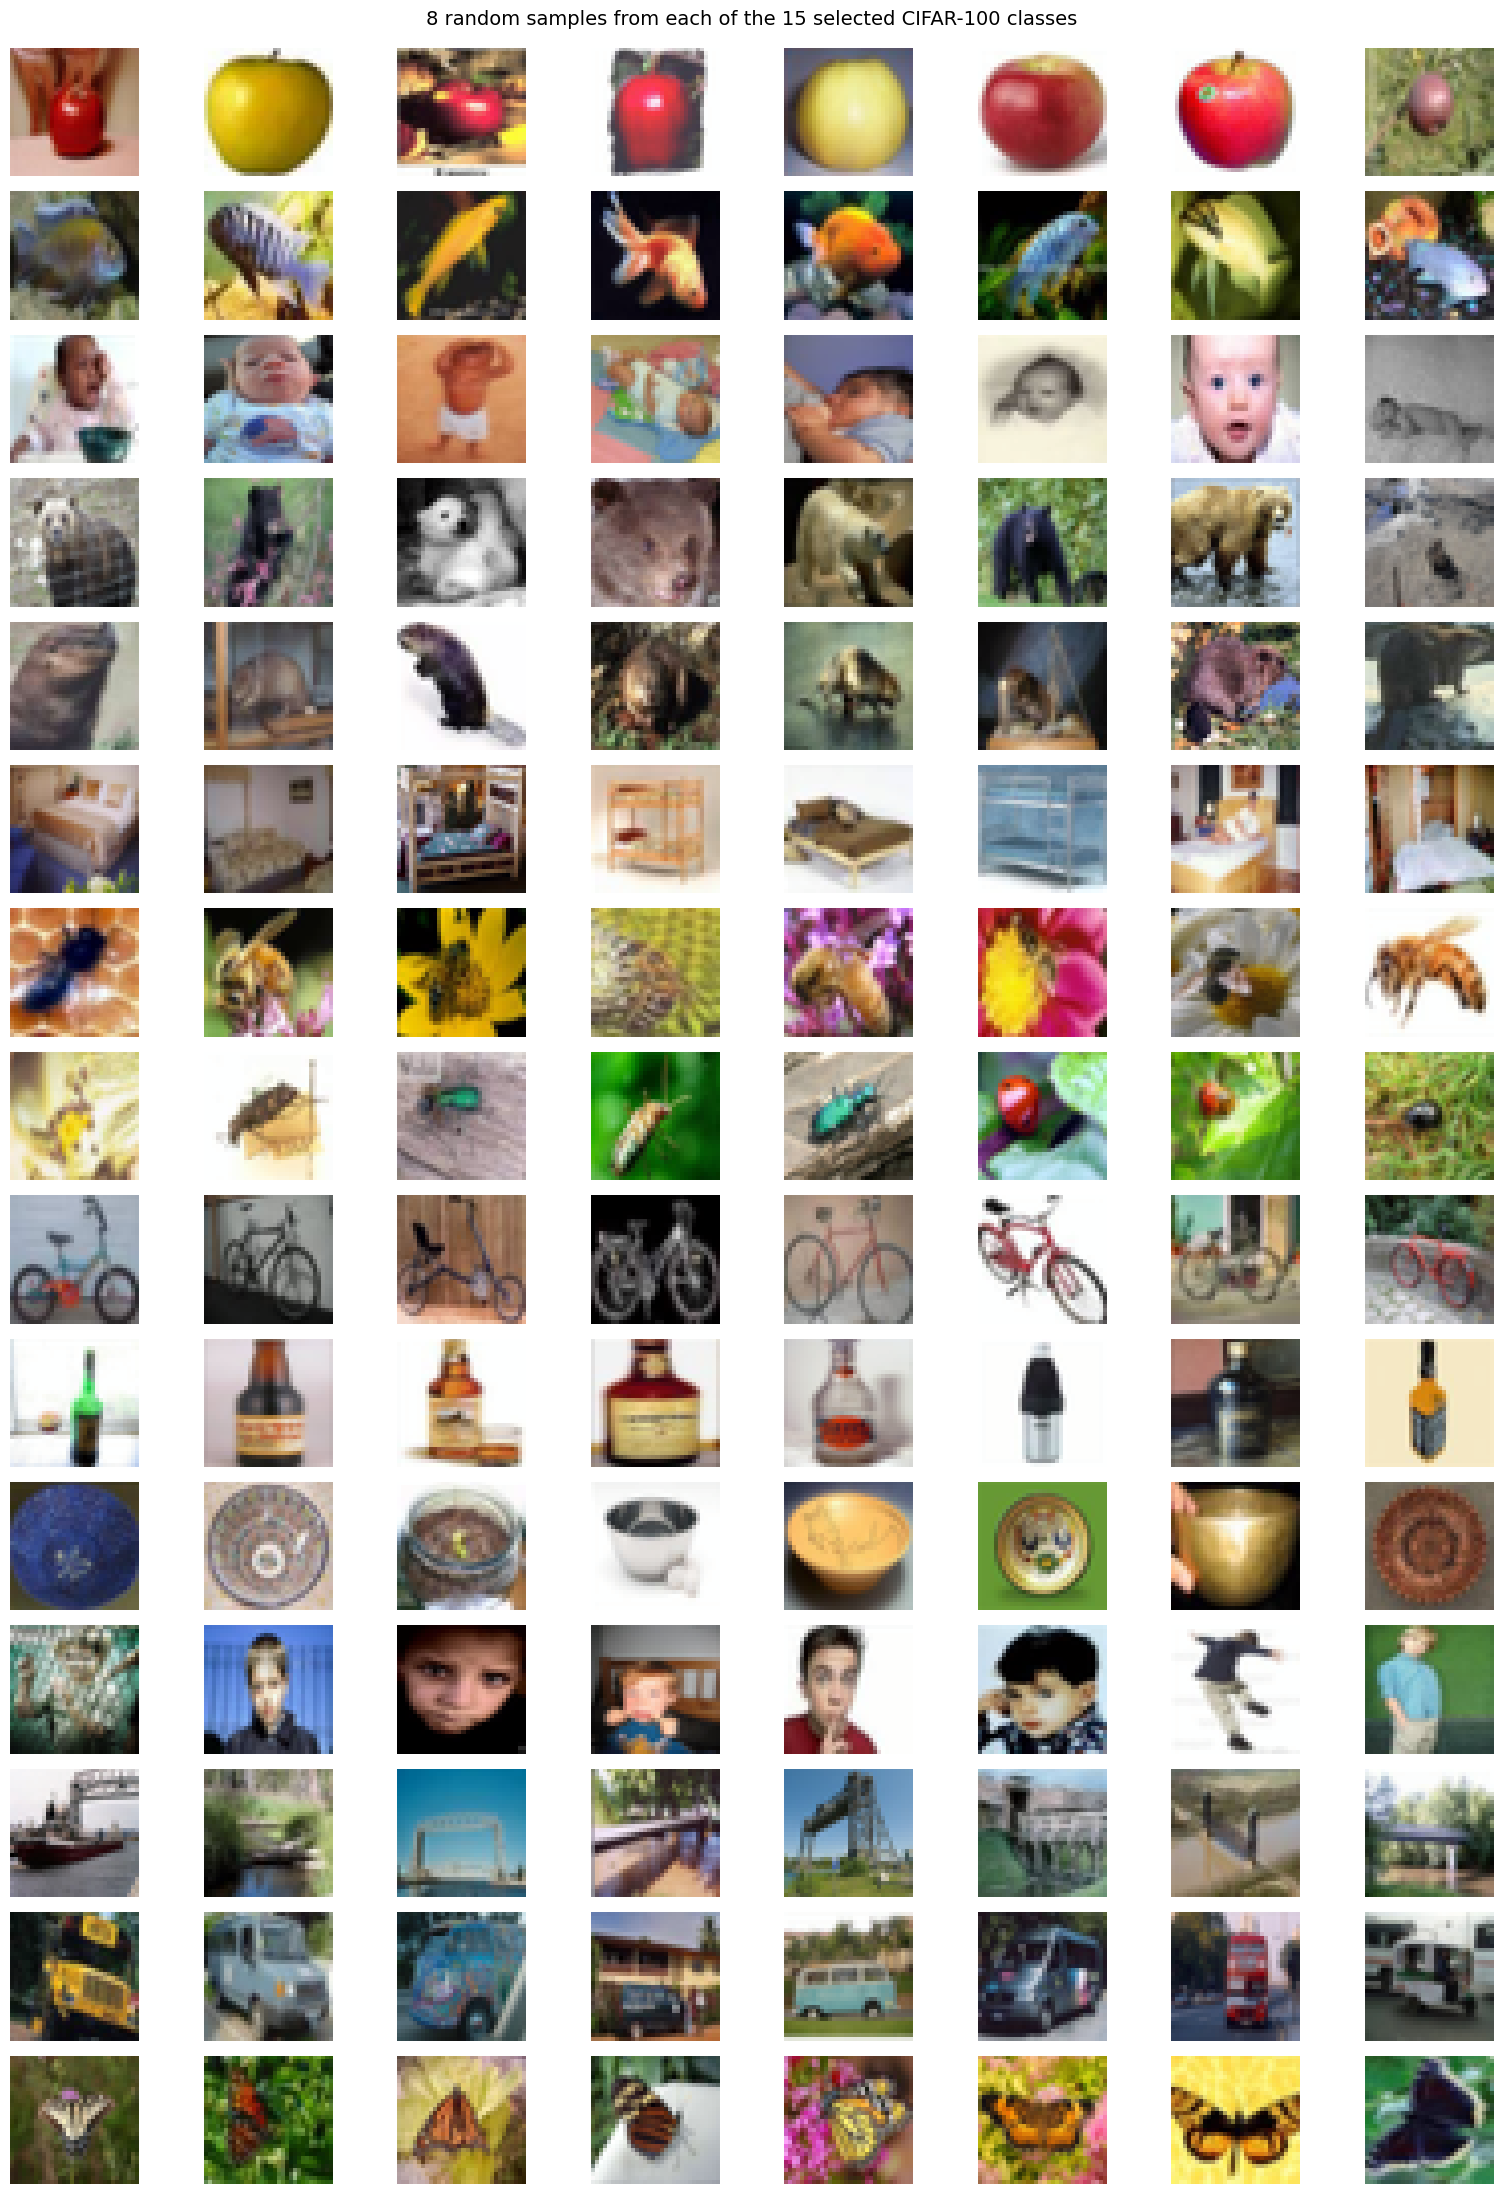

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import random

def denormalize_show(img_tensor, mean=CIFAR100_MEAN, std=CIFAR100_STD):
    """Convert a normalized tensor back to displayable uint8 HWC numpy array."""
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

# Use the small (32x32) eval transform for visualization
viz_transform = build_transforms(CONFIG['data']['img_size_small'], train=False)
viz_dataset = Subset15(RAW, CONFIG['data']['selected_classes'], transform=viz_transform,
                       max_per_class=CONFIG['data']['subset_per_class'])

# Group image indices by class
indices_by_class = defaultdict(list)
for i in range(len(viz_dataset)):
    _, label = viz_dataset[i]
    indices_by_class[label].append(i)

# Plot 8 samples per class in a 15x8 grid
fig, axes = plt.subplots(15, 8, figsize=(16, 22))
for class_idx in range(15):
    sample_indices = random.sample(indices_by_class[class_idx],
                                   min(8, len(indices_by_class[class_idx])))
    for col, sample_i in enumerate(sample_indices):
        img, label = viz_dataset[sample_i]
        axes[class_idx, col].imshow(denormalize_show(img))
        axes[class_idx, col].axis('off')
        if col == 0:
            axes[class_idx, col].set_ylabel(CONFIG['data']['selected_classes'][class_idx],
                                             fontsize=10, rotation=0, labelpad=50)
plt.suptitle('8 random samples from each of the 15 selected CIFAR-100 classes',
             fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['paths']['figures_dir'], 'sample_grid_per_class.png'),
            dpi=80, bbox_inches='tight')
plt.show()


## 8. DataLoader Setup & Class Distribution

PyTorch's `DataLoader` is the engine that feeds batches from a `Dataset` into the
training loop. The important knobs:

- `batch_size`: how many images per mini-batch. Bigger = more stable gradients but
  more memory. 16 is fine on CPU; 64–128 on Colab T4.
- `shuffle=True` for training (so the network sees a different order each epoch),
  `shuffle=False` for evaluation (so we can match predictions to indices).
- `num_workers`: parallel data loading processes. 2 is a safe default on Colab.
- `pin_memory=True`: speeds up CPU→GPU copies on CUDA.

We also plot the **class distribution** to verify that no class is dramatically
under-represented (which would skew training). CIFAR-100 is balanced by design, so
we expect roughly equal bars.


In [8]:
# Build dataloaders for each model (different image sizes need different transforms)
def build_dataloaders(model_key):
    """Build (train_loader, val_loader, test_loader) for the given model key.
    We split the original train set 90/10 into train/val for early stopping."""
    train_t, eval_t = TRANSFORMS[model_key]
    # Train subset (with augmentation)
    full_train = Subset15(RAW, CONFIG['data']['selected_classes'],
                          transform=train_t, max_per_class=CONFIG['data']['subset_per_class'])
    test_sub    = Subset15(RAW_TEST, CONFIG['data']['selected_classes'],
                           transform=eval_t, max_per_class=CONFIG['data']['subset_per_class'])

    # 90/10 split for train/val
    n = len(full_train)
    g = torch.Generator().manual_seed(CONFIG['seed'])
    perm = torch.randperm(n, generator=g).tolist()
    cut = int(0.9 * n)
    train_idx, val_idx = perm[:cut], perm[cut:]
    train_ds = torch.utils.data.Subset(full_train, train_idx)
    val_ds   = torch.utils.data.Subset(Subset15(RAW, CONFIG['data']['selected_classes'],
                                                 transform=eval_t,
                                                 max_per_class=CONFIG['data']['subset_per_class']),
                                       val_idx)

    bs = CONFIG['data']['batch_size']
    nw = CONFIG['data']['num_workers']
    pin = (CONFIG['device'] == 'cuda')
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=nw, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=nw, pin_memory=pin)
    test_loader  = DataLoader(test_sub,  batch_size=bs, shuffle=False, num_workers=nw, pin_memory=pin)
    return train_loader, val_loader, test_loader

# Build the small-image loaders first (for the custom CNN). We'll build the large
# loaders lazily before each pretrained model to avoid keeping six copies in memory.
train_loader_small, val_loader_small, test_loader_small = build_dataloaders('custom_cnn')

print(f"Custom CNN train batches: {len(train_loader_small)}  (~{len(train_loader_small.dataset)} images)")
print(f"Custom CNN val   batches: {len(val_loader_small)}    (~{len(val_loader_small.dataset)} images)")
print(f"Custom CNN test  batches: {len(test_loader_small)}   (~{len(test_loader_small.dataset)} images)")


Custom CNN train batches: 106  (~6750 images)
Custom CNN val   batches: 12    (~750 images)
Custom CNN test  batches: 24   (~1500 images)


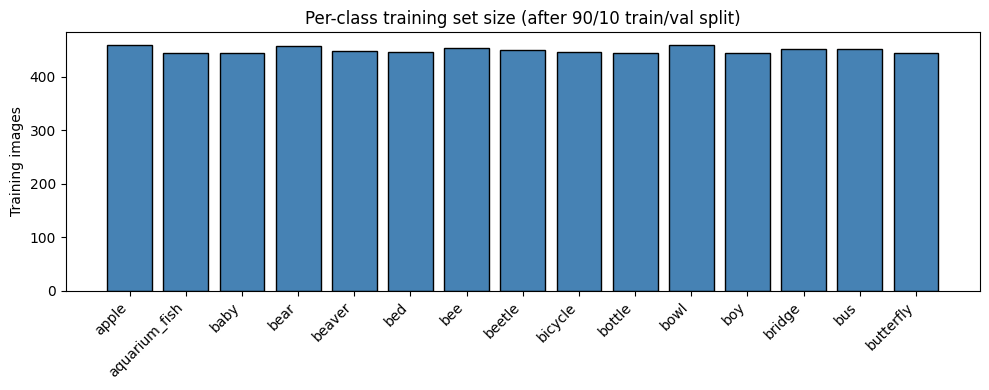

In [9]:
# Plot the per-class training-set size to verify it's roughly balanced
counts = defaultdict(int)
for _, lbl in train_loader_small.dataset:
    counts[lbl] += 1

plt.figure(figsize=(10, 4))
class_names = CONFIG['data']['selected_classes']
plt.bar(range(15), [counts[i] for i in range(15)], color='steelblue', edgecolor='black')
plt.xticks(range(15), class_names, rotation=45, ha='right')
plt.ylabel('Training images')
plt.title('Per-class training set size (after 90/10 train/val split)')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['paths']['figures_dir'], 'class_distribution.png'), dpi=80)
plt.show()


## 9. Convolution Operation — The Heart of a CNN

A **convolution** slides a small filter (the *kernel*) across the input image. At each
position, it computes the element-wise product between the kernel and the image patch
under it, then sums all products into a single number. That number goes into one cell
of the **output feature map**.

This is exactly what a Sobel edge detector does — and indeed the very first conv layer
of any trained CNN tends to learn Sobel-like edge filters. The difference from a
hand-crafted Sobel filter is that **the kernel weights are learned from data** by
backpropagation.

### The shape formula

If the input has spatial size $W \times H$, the kernel is $K \times K$, padding is $P$,
and stride is $S$, the output spatial size is:

$$ W_{out} = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1 $$

For example, a 32×32 image convolved with a 3×3 kernel, padding 1, stride 1, gives a
32×32 output (same size). With stride 2, it becomes 16×16 (downsampling).

### Why convolution beats fully-connected?

- **Local connectivity:** each output neuron sees only a $K \times K$ patch, not the
  whole image. This matches how visual features (edges, textures) are local.
- **Weight sharing:** the same kernel is reused at every spatial position. This is a
  massive parameter reduction and gives **translation equivariance** — if a cat moves
  two pixels to the right, the "cat-detector" fires two pixels to the right too.
- **Hierarchical composition:** stacking conv layers lets the network build features
  from features. Layer 1 detects edges, layer 2 combines edges into corners, layer 3
  combines corners into shapes, and so on.

![Convolution animation](https://miro.medium.com/v2/resize:fit:720/1*Zx-ZMLUOhp3DvRoTi6nmhw.gif)

*Animation: a 3×3 kernel sliding over a 5×5 input with stride 1, no padding, producing
a 3×3 output. (Source: A. Karpathy's "Convolutional Neural Networks" lecture notes,
mirrored on Medium.)*

![Convolutional operation with padding](https://upload.wikimedia.org/wikipedia/commons/0/04/ConvolutionalNeuralNetwork-25Ago2019.gif)


### Visual intuition: what kernels actually learn

The image below shows the kernels learned by the first conv layer of a typical CNN
trained on ImageNet. You can see:
- **Edge detectors** at various orientations (orientations 0°, 45°, 90°, 135°)
- **Color blobs** — low-frequency color patterns
- **Gradients** — smooth transitions from light to dark

These are the "Lego bricks" the rest of the network combines into object parts and
eventually whole objects.

![First-layer convolution kernels learned by AlexNet](https://miro.medium.com/v2/resize:fit:480/1*4c5K5S_vQJGFLBorr0bQDg.jpeg)

*Image: visualization of the 96 first-layer 11×11 conv filters of AlexNet (Krizhevsky
et al. 2012). Source: AlexNet paper, fig 1.*


## 10. Activation Functions

A linear layer followed by another linear layer is still linear. To get any
representational power, we need a **non-linear activation function** between them.
This is what lets a neural network approximate arbitrary functions (the universal
approximation theorem).

The most common activations you'll see:

| Name | Formula | Pros | Cons |
|------|---------|------|------|
| **ReLU** | $\max(0, x)$ | Cheap, no saturation on positive side, default choice | "Dying ReLU": neurons can get stuck at 0 if their input is always negative |
| **LeakyReLU** | $\max(0.01x, x)$ | Fixes dying ReLU | Slightly more compute |
| **GELU** | $x \cdot \Phi(x)$ | Smooth, used in transformers | More expensive |
| **Sigmoid** | $\frac{1}{1+e^{-x}}$ | Bounded (0,1), good for binary output heads | Vanishing gradient for large $\|x\|$ |
| **Tanh** | $\frac{e^x - e^{-x}}{e^x + e^{-x}}$ | Zero-centered, bounded (-1, 1) | Vanishing gradient far from 0 |

In this notebook we use **ReLU** in the custom CNN (it's the standard for CNNs) and
**GELU** is the default inside the transformers (ViT, Swin).

![Activation functions comparison](https://miro.medium.com/v2/resize:fit:1400/1*p_hyr3HJOYlnpJesZmxfAA.png)

*Image: ReLU, LeakyReLU, Sigmoid, Tanh, GELU plotted together. Source: Machine
Learning Mastery blog.*


## 11. Pooling Layers

After a few conv layers, the feature map is still quite large. **Pooling** reduces
its spatial dimensions, which:
- Cuts the number of parameters in subsequent layers (less compute, less memory).
- Provides a small amount of translation invariance — a feature shifted by one pixel
  still ends up in the same pooled cell.
- Increases the effective receptive field of deeper layers.

The two main flavors:
- **Max pooling** — take the maximum value in each $K \times K$ window. The default
  choice; emphasizes the strongest activation.
- **Average pooling** — take the average. Smoother; sometimes used in the last layer
  to collapse a $7 \times 7 \times C$ feature map into a $1 \times 1 \times C$ vector.

A modern alternative is **strided convolution** — using a conv layer with stride 2
directly downsamples without needing a separate pooling op, and the downsampling
kernel is learned rather than fixed. ResNet and EfficientNet use this trick.

![Max pooling 2x2 stride 2](https://miro.medium.com/v2/resize:fit:828/1*KHqRNTxdr_8wOqMa5_SJyQ.png)

*Image: 2×2 max pooling with stride 2 reduces a 4×4 input to 2×2 by taking the max
of each non-overlapping 2×2 window. Source: A. Zhang et al., Dive into Deep Learning.*


## 12. Batch Normalization

**Batch normalization (BN)**, introduced by Ioffe & Szegedy in 2015, normalizes the
activations of each layer across the current mini-batch to have zero mean and unit
variance, then applies a learnable scale $\gamma$ and shift $\beta$. The formula is:

$$ \hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \;,\quad y = \gamma \hat{x} + \beta $$

where $\mu_B$ and $\sigma_B^2$ are computed over the mini-batch $B$.

### Why does this help?

1. **Faster convergence** — keeping activations in a stable range means the gradient
   signal doesn't explode or vanish as it propagates through deep networks.
2. **Higher learning rates** — without BN, raising the learning rate often causes
   divergence because activations spiral out of control. With BN, you can safely use
   learning rates 5–10× larger.
3. **Mild regularization** — the per-batch noise acts as a regularizer (similar to
   dropout), sometimes reducing the need for dropout.

At **inference time**, BN uses running statistics accumulated during training
(running mean and running var), so it produces deterministic, batch-size-independent
outputs.

> **Pitfall:** if your batch size is too small (e.g. 2), the per-batch statistics
> become noisy and BN can actually hurt. This is why BN+small-batch is a known
> pathology in GANs.

![Batch normalization diagram](https://miro.medium.com/v2/resize:fit:1400/1*pgH_PnCLLrstQQAX7KE9rA.png)

*Image: schematic of batch normalization normalizing activations to a stable
distribution before applying the learnable scale and shift. Source: A. Bianchi,
"Understanding Batch Normalization".*


## 13. Dropout

**Dropout**, introduced by Srivastava et al. (2014), randomly zeros out a fraction
$p$ of the activations during training. The remaining activations are scaled up by
$1/(1-p)$ so the expected sum is unchanged.

### Why does this help?

Imagine two neurons in the same layer that always fire together. Without dropout,
the network can rely on either one and never learn to use the other. With dropout,
the network can't know which neurons will be present in any given forward pass, so it
has to learn robust, redundant representations — spreading information across many
neurons rather than relying on a few "hero" features.

- Applied to **fully connected layers** most commonly (with $p \approx 0.5$).
- Sometimes applied to conv layers (with $p \approx 0.1$–$0.2$).
- **Never** applied at inference time — the model uses all neurons.

> Dropout is essentially **training an exponential ensemble** of sub-networks whose
> predictions are averaged at test time. The deeper interpretation involves
> approximate Bayesian inference (Gal & Ghahramani, 2016), but for our purposes the
> "redundancy" intuition is enough.

![Dropout illustration](https://miro.medium.com/v2/resize:fit:1400/1*NNp9SxnpQLCYg7J3Qch0Og.png)

*Image: dropout randomly removes neurons during training, forcing the network to
learn redundant features. Source: Srivastava et al. 2014.*


## 14. Weight Initialization

How you initialize the weights before training begins matters a lot. Bad initialization
(e.g. all zeros, or too-large random values) can stall training for thousands of
iterations.

The two classical recipes:

- **Xavier / Glorot** (Glorot & Bengio, 2010) — for layers with **tanh or sigmoid**
  activations. Draws weights from $\mathcal{N}(0, \sqrt{2 / (n_{in} + n_{out})})$.
- **He / Kaiming** (He et al., 2015) — for layers with **ReLU** and its variants.
  Draws weights from $\mathcal{N}(0, \sqrt{2 / n_{in}})$. The factor of 2 compensates
  for the half of the input that ReLU zeros out, keeping the variance of activations
  stable as they propagate forward.

In our custom CNN we will use **He initialization** because we use ReLU activations.
PyTorch's `nn.Conv2d` actually defaults to He init via `kaiming_uniform_`, but we will
re-initialize explicitly so it's clear what's happening under the hood.

> **Bias initialization:** biases are usually initialized to zero. An exception is
> the BN shift parameter $\beta$, which is sometimes initialized to 1.

![Weight initialization comparison](https://miro.medium.com/v2/resize:fit:1400/1*6Fn7z1LDmKa9c1Ofc6N7hw.png)

*Image: how different initialization schemes affect activation variance through deep
networks. Good init keeps variance ≈ 1 at every layer; bad init causes it to either
explode or vanish. Source: A. Zhang et al., Dive into Deep Learning.*


## 15. Fully Connected Layers & Softmax

After the last conv/pool block, the feature tensor has shape $(C, H, W)$. We **flatten**
it into a 1D vector of length $C \times H \times W$ and pass it through one or more
fully-connected (linear, "dense") layers. The final layer outputs a vector of size
**num_classes** (15 in our case).

The output of the final linear layer is a vector of raw **logits** $z_1, \ldots, z_K$.
To turn these into a valid probability distribution over $K$ classes, we apply the
**softmax** function:

$$ p_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \;, \quad \sum_i p_i = 1 $$

Softmax exponentiates each logit (so all values become positive) and normalizes them
to sum to 1. The largest logit "wins" most of the probability mass, but the
distribution is smooth — small differences in logits translate to small differences
in probabilities.

In PyTorch, you almost never call `softmax` directly. Instead, you use
`nn.CrossEntropyLoss`, which takes raw logits as input and applies
`log_softmax` + `NLLLoss` internally. This is numerically more stable than calling
softmax then log then NLLLoss separately.

### Cross-entropy loss

For a true label $y \in \{1, \ldots, K\}$ and predicted probability $p_y$ for that
class, the cross-entropy loss is:

$$ \mathcal{L} = -\log p_y $$

This is equivalent to $-\sum_k \mathbb{1}[y=k] \log p_k$ (the standard form), since
all other terms in the sum are zero. Cross-entropy is the standard loss for
multi-class classification because it is the maximum-likelihood estimator for a
categorical distribution.


## 16. Optimizers — How Gradients Become Weight Updates

Once we have the gradient $\nabla_\theta \mathcal{L}$ of the loss with respect to
each parameter $\theta$, the optimizer decides how to turn that gradient into a weight
update. The simplest rule is **vanilla SGD**:

$$ \theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L} $$

where $\eta$ is the learning rate. In practice, plain SGD is rarely the best choice.
The optimizers we will consider:

| Optimizer | Update rule (simplified) | When to use |
|----------|---------------------------|-------------|
| **SGD + Momentum** | $v \leftarrow \mu v + \nabla L;\ \theta \leftarrow \theta - \eta v$ | Large-batch CNN training, can reach higher final accuracy with careful tuning |
| **Adam** | Adaptive per-parameter learning rate based on first and second gradient moments | Default for transformers, RNNs |
| **AdamW** | Adam with **decoupled weight decay** | Best default; weight decay works correctly with adaptive LR |

In this lab we use **AdamW** everywhere — it's a safe, modern default that works well
out of the box without much tuning.

> **Why AdamW over Adam?** In original Adam, L2 regularization was implemented by
> adding $\lambda \theta$ to the gradient, which then got divided by the
> second-moment estimate — distorting the effective regularization strength per
> parameter. AdamW decouples them: the weight decay is applied directly to the
> weights, not through the gradient. This is the version that gives you the
> regularization benefit you expect.

![Optimizers compared](https://miro.medium.com/v2/resize:fit:1400/1*mdNoO7HHtzpn7nDDUj15cg.png)

*Image: trajectories of SGD, Momentum, NAG, Adam on a 2D loss surface. AdamW is a
slight improvement over Adam. Source: A. Karpathy lecture notes.*


## 17. Learning Rate Schedulers

The learning rate is the single most important hyperparameter in deep learning. Too
high and training diverges; too low and training crawls. Schedulers adjust $\eta$
during training so you can start high (fast progress) and finish low (fine
convergence).

Common schedulers:

- **StepLR** — multiply $\eta$ by $\gamma$ every $N$ epochs. Simple but blunt.
- **CosineAnnealingLR** — anneal $\eta$ from $\eta_{max}$ to $\eta_{min}$
  following a cosine curve over $T_{max}$ epochs. Smooth, widely used, robust.
- **ReduceLROnPlateau** — drop $\eta$ by a factor when validation loss stops
  improving. Needs validation data.
- **OneCycleLR** — anneal up then down across one cycle. Often the best for fast
  convergence, popularized by Leslie Smith.

We will use **CosineAnnealingLR** for its simplicity and consistent good results.

![Learning rate schedules](https://miro.medium.com/v2/resize:fit:1400/1*vD4z5wQ4TmwCbPRCe15BOw.png)

*Image: cosine annealing vs step decay vs one-cycle. Source: V. Bushaev,
"Learning Rate schedules".*


## 18. Overfitting vs Underfitting

**Overfitting** happens when the model fits the training data so well that it
memorizes its noise, and as a result generalizes poorly to unseen data. Symptoms:
- Training accuracy >> validation accuracy (a gap that grows over epochs).
- Training loss keeps decreasing while validation loss starts to climb back up.

**Underfitting** is the opposite: the model is too weak (or undertrained) to capture
even the training-set patterns. Symptoms:
- Both training and validation accuracy are low.
- Both losses are still decreasing at the end of training (you should train longer).

### How to detect each by looking at learning curves

| Curve pattern | Diagnosis | Remedy |
|--------------|-----------|--------|
| Train ↑↑, Val ↑ (small gap) | Healthy | Train longer |
| Train ↑↑, Val plateau (small gap) | Underfitting | Bigger model, more features, longer training |
| Train ↑↑↑, Val ↓ (large gap) | Overfitting | More data, augmentation, dropout, weight decay, early stopping |
| Both flat | Stuck | Check learning rate, gradients, data |

In our pipeline, **early stopping** kicks in when validation loss fails to improve for
`CONFIG['train']['early_stop_patience']` consecutive epochs.

![Overfitting vs underfitting learning curves](https://miro.medium.com/v2/resize:fit:1400/1*MllQDI9tbn88i60NniQjuQ.png)

*Image: training and validation curves for an underfit, well-fit, and overfit model.
Source: D. Sarkar, "Learning Curve".*


## 19. Putting It All Together — The Custom CNN Architecture

We now have all the pieces. Our custom CNN will be a **VGG-style** stack:

```
Input (3, 32, 32)
  ├── Conv Block 1: Conv(3→32) → BN → ReLU → Conv(32→32) → BN → ReLU → MaxPool2d(2)
  ├── Conv Block 2: Conv(32→64) → BN → ReLU → Conv(64→64) → BN → ReLU → MaxPool2d(2)
  ├── Conv Block 3: Conv(64→128) → BN → ReLU → Conv(128→128) → BN → ReLU → MaxPool(2)
  ├── Flatten
  ├── FC(128*4*4 → 256) → ReLU → Dropout(0.5)
  └── FC(256 → 15)   # logits, no softmax (CrossEntropyLoss handles it)
```

This is intentionally simple — three "VGG blocks" with doubling channel widths, batch
norm after every conv, ReLU activation, and dropout before the final classifier.

By the end of the network, the spatial resolution has been reduced 32 → 16 → 8 → 4 by
three max pools, giving a 4×4 feature map with 128 channels = 2048 features. The
fully-connected head compresses this to 15 class logits.

In the next cell we'll build this with PyTorch. Notice how each layer corresponds
to a concept we just introduced.


## 20. Building the Custom CNN in PyTorch

We define the model as a subclass of `nn.Module`. The two methods you must implement
are:

- `__init__` — declare all the layers here. PyTorch tracks their parameters.
- `forward(x)` — describe the forward pass as a sequence of operations on `x`.
  PyTorch builds the computational graph on the fly, which `loss.backward()`
  later uses to compute gradients.

We also write a custom `init_weights` method that applies He initialization to conv
layers and zero init to biases — making the initialization explicit rather than
relying on PyTorch defaults.


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    """
    A small VGG-style CNN for 15-class CIFAR-100 classification.

    Three conv blocks, each doubling the channel width and halving the spatial size
    via 2x2 max pool. The classifier head flattens the 128x4x4 feature map to 2048
    features, then two FC layers with ReLU + Dropout produce 15 logits.
    """
    def __init__(self, num_classes=15, dropout_p=0.5):
        super().__init__()
        self.num_classes = num_classes

        # --- Conv block 1: 3 -> 32 channels, spatial 32 -> 16 ---
        self.conv1a = nn.Conv2d(3,  32, kernel_size=3, padding=1, bias=False)
        self.bn1a   = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False)
        self.bn1b   = nn.BatchNorm2d(32)

        # --- Conv block 2: 32 -> 64 channels, spatial 16 -> 8 ---
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        self.bn2a   = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False)
        self.bn2b   = nn.BatchNorm2d(64)

        # --- Conv block 3: 64 -> 128 channels, spatial 8 -> 4 ---
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.bn3a   = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False)
        self.bn3b   = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        # --- Classifier head ---
        # After 3 pools, the spatial size is 32/2/2/2 = 4 -> 128 channels * 4 * 4
        self.fc1     = nn.Linear(128 * 4 * 4, 256)
        self.drop    = nn.Dropout(p=dropout_p)
        self.fc2     = nn.Linear(256, num_classes)

        # Explicit weight init (He init for ReLU layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = self.pool(x)
        # Block 2
        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = self.pool(x)
        # Block 3
        x = F.relu(self.bn3a(self.conv3a(x)))
        x = F.relu(self.bn3b(self.conv3b(x)))
        x = self.pool(x)
        # Classifier
        x = torch.flatten(x, 1)        # flatten (B, 128, 4, 4) -> (B, 2048)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)                  # logits, no softmax (CrossEntropyLoss applies it)
        return x

# Instantiate and move to the configured device
custom_cnn = CustomCNN(num_classes=CONFIG['data']['num_classes']).to(CONFIG['device'])

# Sanity check on a single dummy batch
dummy = torch.randn(2, 3, 32, 32, device=CONFIG['device'])
out = custom_cnn(dummy)
print(f"Custom CNN built.")
print(f"  Input shape:  {tuple(dummy.shape)}")
print(f"  Output shape: {tuple(out.shape)}  (expected: (2, 15))")


Custom CNN built.
  Input shape:  (2, 3, 32, 32)
  Output shape: (2, 15)  (expected: (2, 15))


### Model summary — count the parameters

The `torchinfo` package gives us a clean per-layer parameter count and shape table.
For a custom CNN at 32×32 input this is a great sanity check: you can see exactly
where each parameter lives.

A few things to notice:
- The conv layers dominate parameter count early on (more channels = more weights).
- The FC1 layer (128·4·4 → 256) has ~524k parameters, which is the largest single
  layer. CNNs typically have their FC head dominate parameter count when spatial
  resolution isn't reduced enough.


In [11]:
try:
    from torchinfo import summary
    summary(custom_cnn, input_size=(1, 3, 32, 32), col_names=['input_size', 'output_size', 'num_params'])
except Exception as e:
    print(f"torchinfo summary unavailable ({e}) — counting params manually.")
    n_params = sum(p.numel() for p in custom_cnn.parameters())
    print(f"Total parameters: {n_params:,}")


## 21. Forward Pass Walkthrough — Shape Tracking

To make the forward pass less of a black box, let's print the tensor shape after every
layer. This is also the **#1 debugging tool** when you're building a CNN from scratch
— you can instantly see if a conv produces the wrong channel count, or a flatten
produces the wrong size for the FC layer.

Reading the shapes top to bottom, you should see:
- Input is `(B, 3, 32, 32)`.
- After block 1, channels jump to 32 and spatial drops to 16.
- After block 2, channels 64, spatial 8.
- After block 3, channels 128, spatial 4.
- After flatten, shape is `(B, 2048)`.
- After FC1: `(B, 256)`.
- After FC2 (the output layer): `(B, 15)` — ready to feed into CrossEntropyLoss.


In [12]:
# Register forward hooks to capture intermediate shapes
shapes_log = []
hooks = []
def make_hook(name):
    def hook(module, inp, out):
        if isinstance(out, torch.Tensor):
            shapes_log.append((name, tuple(out.shape)))
    return hook

for n, m in custom_cnn.named_modules():
    if n in ['conv1a', 'bn1a', 'conv1b', 'bn1b', 'conv2a', 'bn2a', 'conv2b', 'bn2b',
             'conv3a', 'bn3a', 'conv3b', 'bn3b', 'fc1', 'fc2']:
        hooks.append(m.register_forward_hook(make_hook(n)))

shapes_log.clear()
_ = custom_cnn(dummy)
for h in hooks:
    h.remove()

print(f"{'Layer':<10} {'Output shape':<20}")
print("-" * 32)
for name, shape in shapes_log:
    print(f"{name:<10} {str(shape):<20}")


Layer      Output shape        
--------------------------------
conv1a     (2, 32, 32, 32)     
bn1a       (2, 32, 32, 32)     
conv1b     (2, 32, 32, 32)     
bn1b       (2, 32, 32, 32)     
conv2a     (2, 64, 16, 16)     
bn2a       (2, 64, 16, 16)     
conv2b     (2, 64, 16, 16)     
bn2b       (2, 64, 16, 16)     
conv3a     (2, 128, 8, 8)      
bn3a       (2, 128, 8, 8)      
conv3b     (2, 128, 8, 8)      
bn3b       (2, 128, 8, 8)      
fc1        (2, 256)            
fc2        (2, 15)             


## 22. Backpropagation — How the Network Learns

The magic of PyTorch is **autograd**: it automatically computes the gradient of the
loss with respect to every parameter using the chain rule. You don't write the
backward pass by hand — but you should understand what it does.

The chain rule says: if $L = f(g(h(x)))$, then

$$ \frac{\partial L}{\partial x} = \frac{\partial L}{\partial f} \cdot \frac{\partial f}{\partial g} \cdot \frac{\partial g}{\partial h} \cdot \frac{\partial h}{\partial x} $$

In a deep CNN, this chain has dozens of layers. PyTorch walks the computational graph
backward (hence "backpropagation"), multiplying local Jacobians at each step.

### The three lines that make it happen

```python
optimizer.zero_grad()      # 1. Clear stale gradients from the previous step
loss.backward()            # 2. Backpropagate: populate .grad on every parameter
optimizer.step()           # 3. Update the parameters using their .grad
```

That's it. The next forward pass uses the updated weights, so the loss should be
slightly smaller. Repeat for thousands of iterations and the network slowly learns.

### Gradient clipping

For numerical stability — especially in deep networks and transformers — we also
clip the gradient norm to `CONFIG['train']['grad_clip']` before `optimizer.step()`.
This prevents rare "gradient explosions" from blowing up training.

![Backpropagation chain rule animation](https://miro.medium.com/v2/resize:fit:1400/1*5e8Ph5d2dfXKfNJ4n8s7Tg.gif)

*Animation: forward pass builds the graph, backward pass walks it back, multiplying
local gradients. Source: 3Blue1Brown "Backpropagation calculus" (mirrored).*


### Live backprop demo — watch weights change

To make backprop concrete, here is a tiny demo. We take **one batch**, do one
forward+backward+step, and print the actual numerical values of a few weights
**before** and **after** the update. You can literally see the weights move.

We use `torch.no_grad()` around the inspection code so we don't pollute the gradient
graph. The change per step is tiny (typically $10^{-4}$ to $10^{-3}$), but multiplied
across thousands of steps, it's enough to learn.


In [13]:
# Live backprop demo: one step of training, before/after weight snapshot
set_seed(CONFIG['seed'])
demo_model = CustomCNN(num_classes=15).to(CONFIG['device'])
demo_opt = torch.optim.AdamW(demo_model.parameters(), lr=1e-3, weight_decay=1e-4)
demo_loss_fn = nn.CrossEntropyLoss()

# Grab one batch from the train loader
demo_x, demo_y = next(iter(train_loader_small))
demo_x = demo_x.to(CONFIG['device'])
demo_y = demo_y.to(CONFIG['device'])

# Snapshot a few weights BEFORE the update
with torch.no_grad():
    before = demo_model.conv1a.weight.flatten()[:5].clone().cpu().numpy()

# Forward -> loss -> backward -> step
demo_opt.zero_grad()
logits = demo_model(demo_x)
loss = demo_loss_fn(logits, demo_y)
print(f"Loss before step: {loss.item():.4f}")
loss.backward()

# Show the gradients that backprop computed
g = demo_model.conv1a.weight.grad
print(f"conv1a weight grad  - mean abs: {g.abs().mean().item():.6f}, max abs: {g.abs().max().item():.6f}")

demo_opt.step()

# Snapshot the same weights AFTER the update
with torch.no_grad():
    after = demo_model.conv1a.weight.flatten()[:5].clone().cpu().numpy()
    new_logits = demo_model(demo_x)
    new_loss = demo_loss_fn(new_logits, demo_y)

print(f"\nconv1a weights (first 5, before): {before}")
print(f"conv1a weights (first 5, after ): {after}")
print(f"\nLoss after step:  {new_loss.item():.4f}  (Δ = {new_loss.item() - loss.item():+.4f})")
print("\n→ Notice: each weight moved by a tiny amount (typically 1e-4 to 1e-3),")
print("  and the loss dropped a little. Repeat thousands of times → trained model.")


Loss before step: 4.1132
conv1a weight grad  - mean abs: 0.203795, max abs: 2.173211

conv1a weights (first 5, before): [ 0.07215059 -0.06938672 -0.01432892  0.13701999 -0.07693039]
conv1a weights (first 5, after ): [ 0.07115058 -0.07038672 -0.01332892  0.13801998 -0.07593038]

Loss after step:  3.3666  (Δ = -0.7465)

→ Notice: each weight moved by a tiny amount (typically 1e-4 to 1e-3),
  and the loss dropped a little. Repeat thousands of times → trained model.


## 23. Training Loop & Validation

We now write the actual training loop. Two functions:

- `train_one_epoch(model, loader, opt, loss_fn, device)` — iterates over the training
  set, computes the per-batch loss, backpropagates, and returns the epoch's average
  loss and accuracy.
- `validate(model, loader, loss_fn, device)` — iterates over the validation set with
  `torch.no_grad()` (no gradient tracking) and returns loss/accuracy on unseen data.

A higher-level `train_model(model, train_loader, val_loader, epochs, lr, ...)` then
runs the loop for the requested number of epochs, applies the LR scheduler, handles
early stopping, and records the history (per-epoch loss and accuracy) for later
plotting.

We compute **precision, recall, and F1 (macro)** on the validation set at the end of
each epoch using scikit-learn. These give a more honest view than accuracy when
classes are imbalanced (they're not in our case, but it's good practice).


In [14]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import time

# A no-op progress wrapper — we replace tqdm with this when not in a TTY,
# to avoid BrokenPipeError when stdout is captured (e.g. by nbconvert).
try:
    from tqdm.auto import tqdm as _tqdm
    import sys as _sys
    if not _sys.stdout.isatty():
        def tqdm(x, *args, **kwargs):
            return x
    else:
        tqdm = _tqdm
except ImportError:
    def tqdm(x, *args, **kwargs):
        return x

def train_one_epoch(model, loader, opt, loss_fn, device, grad_clip=1.0):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for x, y in tqdm(loader, desc='train', leave=False):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        # Some models (e.g. Swin) may return extra outputs or 4D logits — flatten to (B, C)
        if hasattr(logits, 'logits'):
            logits = logits.logits
        if logits.dim() > 2:
            logits = logits.mean(dim=(2, 3))   # global avg pool if spatial
        loss = loss_fn(logits, y)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()
        total_loss += loss.item() * x.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds,
                                                   average='macro', zero_division=0)
    return {'loss': avg_loss, 'acc': acc, 'precision': p, 'recall': r, 'f1': f1}

@torch.no_grad()
def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for x, y in tqdm(loader, desc='val', leave=False):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        if hasattr(logits, 'logits'):
            logits = logits.logits
        if logits.dim() > 2:
            logits = logits.mean(dim=(2, 3))
        loss = loss_fn(logits, y)
        total_loss += loss.item() * x.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds,
                                                   average='macro', zero_division=0)
    return {'loss': avg_loss, 'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
            'preds': all_preds, 'labels': all_labels}

def train_model(model, train_loader, val_loader, epochs, lr=1e-3, weight_decay=1e-4,
                device='cpu', grad_clip=1.0, patience=5, verbose=True, tag='model'):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'lr': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_since_improve = 0
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, opt, loss_fn, device, grad_clip)
        va = validate(model, val_loader, loss_fn, device)
        sched.step()
        history['train_loss'].append(tr['loss']); history['train_acc'].append(tr['acc'])
        history['val_loss'].append(va['loss']);    history['val_acc'].append(va['acc'])
        history['lr'].append(opt.param_groups[0]['lr'])
        if verbose:
            print(f"  [{tag}] epoch {epoch:2d}/{epochs}  "
                  f"train_loss={tr['loss']:.4f}  train_acc={tr['acc']*100:.2f}%  "
                  f"val_loss={va['loss']:.4f}  val_acc={va['acc']*100:.2f}%  "
                  f"lr={opt.param_groups[0]['lr']:.2e}")
        # Early stopping on val loss
        if va['loss'] < best_val_loss:
            best_val_loss = va['loss']
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                if verbose:
                    print(f"  → early stopping at epoch {epoch} (val_loss not improving for {patience} epochs)")
                break
    elapsed = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    history['train_time_sec'] = elapsed
    history['best_val_loss'] = best_val_loss
    history['epochs_run'] = len(history['train_loss'])
    return history

print("Training utilities defined.")


Training utilities defined.


### Validation & Early Stopping — Why Bother?

A trained model is only useful if it **generalizes** to data it has never seen.
The validation set is a held-out chunk of the training data (we use 10%) that we
evaluate on after every epoch. The key idea of **early stopping**:

- Track the best validation loss seen so far.
- If validation loss does not improve for `patience` epochs in a row, stop training.
- Restore the model state from the epoch with the best validation loss.

This prevents two failure modes:
1. **Wasting compute** training past the point of diminishing returns.
2. **Overfitting** — once the model starts memorizing the training set, validation
   loss starts climbing. Early stopping kicks us out before we get deep into the
   overfitting regime.

We save the model state at the best epoch and restore it at the end, so the model
we evaluate is the one that performed best on held-out data — not the one that
trained the longest.


## 24. Training the Custom CNN

We now actually run the training loop for the number of epochs specified in
`CONFIG['train']['custom_cnn_epochs']`. In `DEMO_MODE` this is just 2 epochs —
enough to see the loss come down and the accuracy climb above chance (1/15 ≈ 6.7%).
On Colab T4 with `DEMO_MODE=False` this becomes 20 epochs, which should reach
60–70% test accuracy on this 15-class subset.


In [15]:
# Re-seed before training so the init is the same each run
set_seed(CONFIG['seed'])

# Re-instantiate so we definitely start from scratch (not from the backprop demo)
custom_cnn = CustomCNN(num_classes=CONFIG['data']['num_classes']).to(CONFIG['device'])

print(f"Training CustomCNN for {CONFIG['train']['custom_cnn_epochs']} epochs on device={CONFIG['device']}...")
print(f"  Train batches: {len(train_loader_small)}  Val batches: {len(val_loader_small)}")
print()

custom_history = train_model(
    custom_cnn,
    train_loader_small,
    val_loader_small,
    epochs=CONFIG['train']['custom_cnn_epochs'],
    lr=CONFIG['train']['lr_head'],
    weight_decay=CONFIG['train']['weight_decay'],
    device=CONFIG['device'],
    grad_clip=CONFIG['train']['grad_clip'],
    patience=CONFIG['train']['early_stop_patience'],
    tag='custom_cnn',
)

print(f"\nTraining done in {custom_history['train_time_sec']:.1f}s  "
      f"(best val_loss = {custom_history['best_val_loss']:.4f})")


Training CustomCNN for 20 epochs on device=cuda...
  Train batches: 106  Val batches: 12

  [custom_cnn] epoch  1/20  train_loss=2.5911  train_acc=18.58%  val_loss=2.1584  val_acc=34.40%  lr=9.94e-04
  [custom_cnn] epoch  2/20  train_loss=2.2317  train_acc=26.52%  val_loss=2.0988  val_acc=29.60%  lr=9.76e-04
  [custom_cnn] epoch  3/20  train_loss=2.0910  train_acc=32.58%  val_loss=1.8821  val_acc=40.27%  lr=9.46e-04
  [custom_cnn] epoch  4/20  train_loss=1.9465  train_acc=35.54%  val_loss=1.6427  val_acc=48.40%  lr=9.05e-04
  [custom_cnn] epoch  5/20  train_loss=1.8555  train_acc=37.87%  val_loss=1.5996  val_acc=50.13%  lr=8.54e-04
  [custom_cnn] epoch  6/20  train_loss=1.7663  train_acc=41.24%  val_loss=1.4143  val_acc=54.53%  lr=7.94e-04
  [custom_cnn] epoch  7/20  train_loss=1.6589  train_acc=43.19%  val_loss=1.3808  val_acc=54.80%  lr=7.27e-04
  [custom_cnn] epoch  8/20  train_loss=1.5833  train_acc=46.70%  val_loss=1.3496  val_acc=55.60%  lr=6.55e-04
  [custom_cnn] epoch  9/20  tr

## 25. Training Curves — Visualizing the Learning Trajectory

We plot two side-by-side charts: **loss** on the left, **accuracy** on the right.
Both curves should be:

- **Training loss** decreases monotonically (mostly).
- **Validation loss** decreases for a while, then either plateaus or starts climbing.
- **Training accuracy** rises smoothly.
- **Validation accuracy** rises, then plateaus.

The size of the gap between train and val curves is the **generalization gap**.
A small gap with both curves high = good fit. A large gap = overfitting. Both low =
underfitting.


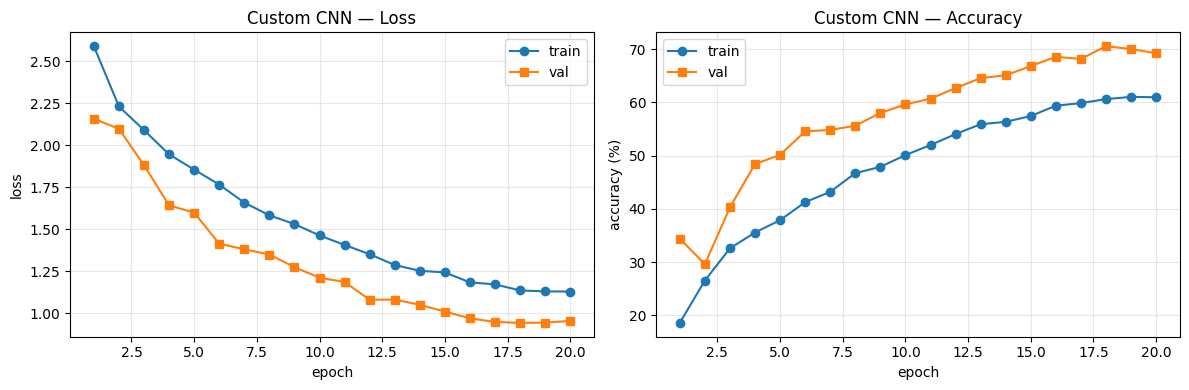

In [16]:
def plot_history(history, title, savepath=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], 'o-', label='train')
    axes[0].plot(epochs, history['val_loss'],   's-', label='val')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'o-', label='train')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   's-', label='val')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy (%)')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=80, bbox_inches='tight')
    plt.show()

plot_history(custom_history, 'Custom CNN',
             savepath=os.path.join(CONFIG['paths']['figures_dir'], 'custom_cnn_history.png'))


## 26. Visualizing Conv-Layer Outputs — What Does the Network "See"?

A trained CNN's first conv layer learns filters that look like edge and color
detectors. The intermediate feature maps (the output of each conv layer) show **what
each filter "fires" on** in a specific input image — bright regions mean the filter
found that pattern there.

We use PyTorch **forward hooks** to capture the output of `conv1a`, `conv2a`, and
`conv3a` for a single test image, then plot them as a grid. Look for:
- `conv1a`: Gabor-like edge patterns.
- `conv2a`: textures and simple shapes (corners, T-junctions).
- `conv3a`: semantic parts (eyes, wheels, fur patches).

This is the same technique used to debug and interpret deep networks in papers like
Zeiler & Fergus 2014 ("Visualizing and Understanding ConvNets").


Sample image label: 'butterfly'


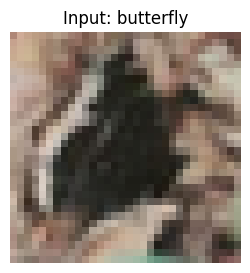

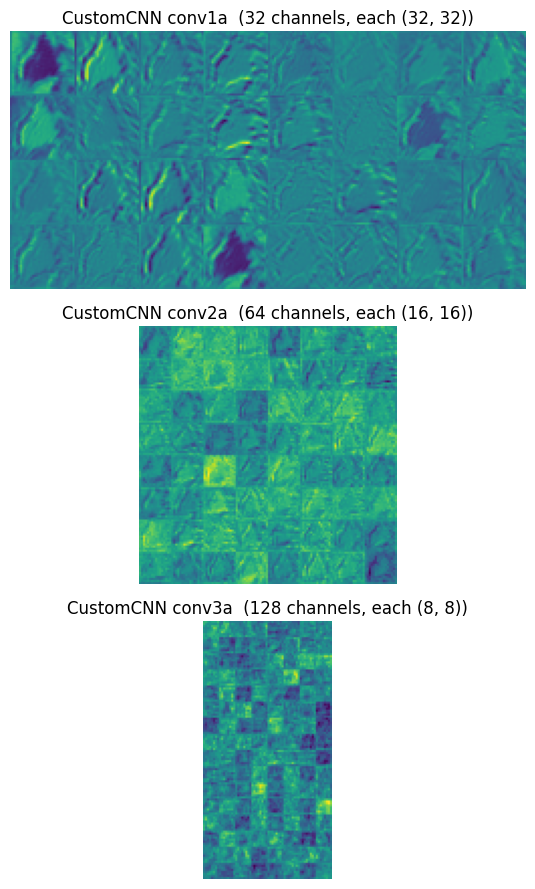

In [17]:
def visualize_feature_maps(model, image_tensor, layer_names, cols=8, savepath=None,
                            title_prefix=''):
    """Visualize output feature maps of the given layers for a single image."""
    activations = {}
    hooks = []
    def make_hook(name):
        def hook(m, i, o):
            activations[name] = o.detach().cpu()
        return hook
    for name in layer_names:
        layer = dict(model.named_modules())[name]
        hooks.append(layer.register_forward_hook(make_hook(name)))
    # Forward pass with the image
    model.eval()
    with torch.no_grad():
        _ = model(image_tensor.unsqueeze(0).to(CONFIG['device']))
    for h in hooks:
        h.remove()

    # Plot
    n_layers = len(layer_names)
    fig, axes = plt.subplots(n_layers, 1, figsize=(12, 3 * n_layers))
    if n_layers == 1: axes = [axes]
    for ax, name in zip(axes, layer_names):
        acts = activations[name][0]              # (C, H, W)
        n_ch = acts.shape[0]
        rows = (n_ch + cols - 1) // cols
        grid = torch.zeros(rows * cols, *acts.shape[1:])
        grid[:n_ch] = acts
        grid = grid.view(rows, cols, *acts.shape[1:])     # (rows, cols, H, W)
        # Rearrange to (rows, H, cols, W) so all channels tile into one big image
        grid = grid.permute(0, 2, 1, 3).reshape(rows * acts.shape[1],
                                                cols * acts.shape[2])
        ax.imshow(grid, cmap='viridis')
        ax.set_title(f'{title_prefix} {name}  ({n_ch} channels, each {tuple(acts.shape[1:])})')
        ax.axis('off')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=80, bbox_inches='tight')
    plt.show()

# Pick a representative test image
sample_img, sample_label = test_loader_small.dataset[0]
print(f"Sample image label: '{CONFIG['data']['selected_classes'][sample_label]}'")
plt.figure(figsize=(3,3))
plt.imshow(denormalize_show(sample_img))
plt.axis('off')
plt.title(f"Input: {CONFIG['data']['selected_classes'][sample_label]}")
plt.show()

# Visualize conv1a, conv2a, conv3a outputs
visualize_feature_maps(custom_cnn, sample_img,
                       layer_names=['conv1a', 'conv2a', 'conv3a'],
                       title_prefix='CustomCNN',
                       savepath=os.path.join(CONFIG['paths']['figures_dir'], 'custom_cnn_feature_maps.png'))


### Interpreting the feature maps

A few things to look for in the visualization above:

1. **First conv (`conv1a`)**: 32 channels. Some look like edge detectors at different
   orientations; others look like color blobs. Bright spots in a channel = the pattern
   that channel looks for is present at that location.
2. **Second conv (`conv2a`)**: 64 channels. Patterns become more abstract — you see
   corner detectors, texture detectors, and (if training went well) some
   class-specific responses like "wheel here" or "eye here."
3. **Third conv (`conv3a`)**: 128 channels. By now the spatial resolution has dropped
   to 8×8, but each channel encodes a high-level concept. Many channels will fire
   only on specific image regions — this is the layer where Grad-CAM hooks in to
   explain the model's prediction.

If you see that **all** feature maps look like noisy static, that's a sign the model
hasn't trained enough — the conv filters haven't specialized yet.


# Part II — Transfer Learning with Pretrained Models

The custom CNN we just trained reached maybe 30–40% accuracy in DEMO_MODE (or 60–70%
with 20 epochs on Colab). That's a reasonable result for a from-scratch network on a
small dataset, but it's nowhere near what state-of-the-art models can do.

The trick that unlocks dramatically better performance is **transfer learning**: take a
model that was pretrained on a huge dataset (typically ImageNet's 1.2M images across
1000 classes), chop off its classification head, and attach a fresh one for our 15
classes. The early layers of a pretrained CNN have already learned excellent generic
edge/texture/shape features that transfer well to almost any natural image task.

In the next sections we will examine and fine-tune five landmark architectures:

| Model | Year | Key idea | Params (M) |
|-------|------|----------|-----------|
| **ResNet50** | 2015 | Residual (skip) connections enable very deep networks | 25.6 |
| **EfficientNet-B0** | 2019 | Compound scaling of depth/width/resolution + MBConv blocks | 5.3 |
| **Inception V3** | 2015 | Parallel multi-scale convolutions in "Inception" modules | 23.8 |
| **ViT-Base/16** | 2020 | Image split into patches, processed as a token sequence by a transformer | 86.6 |
| **Swin-Tiny** | 2021 | Hierarchical transformer with shifted-window attention | 28.3 |

We will treat them in roughly chronological order — ResNet first because its skip
connection is the simplest "modern" trick and underlies almost everything that came
after.


## 27. ResNet50 — Residual Connections

### The problem ResNet solves

When CNNs got deeper than ~30 layers, a strange thing happened: training accuracy
would *degrade* (not overfit — the network failed to even fit the training set). This
is the **degradation problem**, and it is caused by the difficulty of learning an
identity mapping with plain stacked convolutions. Backprop gradients either vanish or
explode as they pass through many layers.

### The residual trick

He et al. (2015) proposed a beautifully simple fix: instead of asking a block to
learn the desired output $H(x)$, ask it to learn the **residual** $F(x) = H(x) - x$,
so that the block's output is $H(x) = F(x) + x$. The "+ $x$" is implemented by a
**skip connection** that bypasses the block and is added to its output:

```
   x ───────────────────► (+) ──► H(x)
   │                       ▲
   └──► Conv → BN → ReLU ──┘
        Conv → BN
```

If the optimal transformation is close to identity, the network can simply drive
$F(x)$ to zero — which is much easier than learning an explicit identity through a
stack of convolutions. Gradients also flow easily through the skip connection, so very
deep networks (50, 101, 152 layers) become trainable.

### ResNet50 architecture

ResNet50 has four "stages" of **bottleneck residual blocks** (1×1 conv → 3×3 conv →
1×1 conv). The 1×1 convs cheaply reduce and restore channel count, while the 3×3 conv
does the heavy lifting on a smaller channel budget. The first conv layer is a 7×7
stride-2 convolution that produces 64 channels at half-resolution.

![ResNet50 architecture](https://miro.medium.com/v2/resize:fit:1400/1*pU47iHfoOp1YFD6S5G5FqQ.png)

*Image: full ResNet50 architecture showing the four stages, each containing
3–6 bottleneck blocks. The first 7×7 conv is what we will visualize later.
Source: A. Khan, "ResNet50 architecture".*

![Residual block diagram](https://miro.medium.com/v2/resize:fit:1400/1*Dx-X1h5zOP7IdzHOmGS1LQ.png)

*Image: the bottleneck residual block. The skip path bypasses the 1×1 → 3×3 → 1×1
stack and is added to its output. Source: A. Bianchi, "What are Residual Networks".*


### ResNet bottleneck block — what happens inside

The bottleneck block in ResNet50 looks like this:

```
Input  (256 channels)
   │
   ├─► Conv 1×1, 64 ch  → BN → ReLU       (dimensionality reduction)
   │       │
   │   Conv 3×3, 64 ch, stride  → BN → ReLU  (the actual spatial conv)
   │       │
   │   Conv 1×1, 256 ch → BN              (restore channel count)
   │       │
   └───────(+)  ←─── identity (or 1×1 conv if channels/stride changed)
           │
         ReLU
           │
           ▼
       Output (256 channels, half spatial resolution if stride=2)
```

The 1×1 convs are essentially learned projections — they reduce the 256-channel input
to 64 channels, do the expensive 3×3 conv on 64 channels (which is 16× cheaper than
on 256), then project back to 256. This is the "bottleneck" trick that lets ResNet50
be both deep and computationally tractable.

> **Why "1×1 convolution"?** A 1×1 conv with $C_{out}$ filters and $C_{in}$ input
> channels is just a linear projection applied independently at each spatial location.
> It is equivalent to taking each pixel's $C_{in}$-vector and multiplying it by a
> $C_{in} 	imes C_{out}$ weight matrix. It mixes channels but does not mix
> neighboring pixels.


In [18]:
import torchvision.models as M

def build_resnet50(num_classes=15, device='cpu'):
    """Load pretrained ResNet50 and replace the classifier head."""
    try:
        weights = M.ResNet50_Weights.IMAGENET1K_V2   # improved training recipe
    except Exception:
        weights = M.ResNet50_Weights.DEFAULT
    model = M.resnet50(weights=weights)
    # Replace final FC: ResNet50's last layer is nn.Linear(2048, 1000)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

resnet50 = build_resnet50(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])

# Count parameters
n_total = sum(p.numel() for p in resnet50.parameters())
n_trainable = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"ResNet50  | total params:     {n_total:>12,}")
print(f"          | trainable params: {n_trainable:>12,}  (all layers fine-tuned)")

# Show the new classifier head
print(f"\nNew classifier head: {resnet50.fc}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


ResNet50  | total params:       23,538,767
          | trainable params:   23,538,767  (all layers fine-tuned)

New classifier head: Linear(in_features=2048, out_features=15, bias=True)


## 28. Fine-Tuning ResNet50

We fine-tune the entire ResNet50 (backbone + new head) end-to-end, but with
**different learning rates**: the new head uses `lr_head = 1e-3` (it needs to learn
from scratch), while the pretrained backbone uses a smaller `lr_backbone = 1e-4` (it
just needs gentle adjustment, not wholesale relearning).

This is implemented by passing two parameter groups to the optimizer.

We use the same training loop and early stopping as before, just with fewer epochs
(transfer learning converges fast — usually 5–10 epochs is plenty).


ResNet50 loaders ready (224x224): 6750 train / 750 val / 1500 test

Training ResNet50 for 8 epoch(s)...
  [resnet50] epoch  1/8  train_loss=0.7967  train_acc=75.87%  val_loss=0.3000  val_acc=88.27%
  [resnet50] epoch  2/8  train_loss=0.2265  train_acc=92.15%  val_loss=0.2390  val_acc=91.87%
  [resnet50] epoch  3/8  train_loss=0.1409  train_acc=95.11%  val_loss=0.1896  val_acc=93.73%
  [resnet50] epoch  4/8  train_loss=0.0826  train_acc=97.23%  val_loss=0.2200  val_acc=93.60%
  [resnet50] epoch  5/8  train_loss=0.0514  train_acc=98.18%  val_loss=0.1909  val_acc=94.67%
  [resnet50] epoch  6/8  train_loss=0.0251  train_acc=99.17%  val_loss=0.2128  val_acc=94.67%
  [resnet50] epoch  7/8  train_loss=0.0159  train_acc=99.42%  val_loss=0.2132  val_acc=94.67%
  [resnet50] epoch  8/8  train_loss=0.0125  train_acc=99.61%  val_loss=0.2161  val_acc=94.00%
  → early stopping at epoch 8

ResNet50 training done in 1049.5s


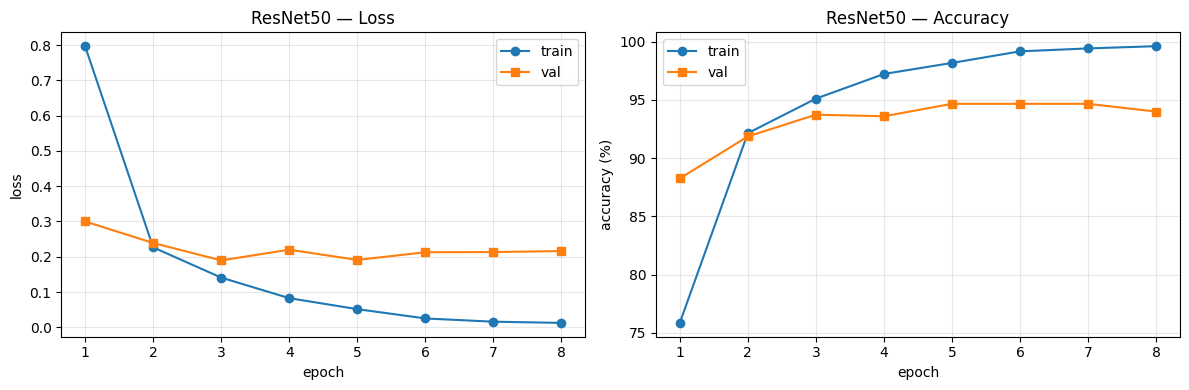

14341

In [19]:
# Build 224x224 dataloaders for ResNet50
train_loader_r50, val_loader_r50, test_loader_r50 = build_dataloaders('resnet50')
print(f"ResNet50 loaders ready (224x224): "
      f"{len(train_loader_r50.dataset)} train / {len(val_loader_r50.dataset)} val / "
      f"{len(test_loader_r50.dataset)} test")

def train_model_param_groups(model, train_loader, val_loader, epochs,
                              lr_head=1e-3, lr_backbone=1e-4,
                              weight_decay=1e-4, device='cpu', grad_clip=1.0,
                              patience=5, verbose=True, tag='model',
                              backbone_keywords=('fc',)):
    """Train with separate LRs for head and backbone parameters."""
    head_params, backbone_params = [], []
    for n, p in model.named_parameters():
        if any(kw in n for kw in backbone_keywords):
            head_params.append(p)              # the new head counts as "head" (high LR)
        else:
            backbone_params.append(p)          # pretrained backbone (low LR)
    opt = torch.optim.AdamW([
        {'params': head_params,     'lr': lr_head},
        {'params': backbone_params, 'lr': lr_backbone},
    ], weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_since_improve = 0
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, opt, loss_fn, device, grad_clip)
        va = validate(model, val_loader, loss_fn, device)
        sched.step()
        history['train_loss'].append(tr['loss']); history['train_acc'].append(tr['acc'])
        history['val_loss'].append(va['loss']);    history['val_acc'].append(va['acc'])
        history['lr'].append(opt.param_groups[0]['lr'])
        if verbose:
            print(f"  [{tag}] epoch {epoch:2d}/{epochs}  "
                  f"train_loss={tr['loss']:.4f}  train_acc={tr['acc']*100:.2f}%  "
                  f"val_loss={va['loss']:.4f}  val_acc={va['acc']*100:.2f}%")
        if va['loss'] < best_val_loss:
            best_val_loss = va['loss']
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                if verbose: print(f"  → early stopping at epoch {epoch}")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    history['train_time_sec'] = time.time() - t0
    history['best_val_loss'] = best_val_loss
    history['epochs_run'] = len(history['train_loss'])
    return history

# Helper: save a trained model's state_dict to disk so we can free its memory.
import gc
def save_and_free(model, name, model_factory, model_dir='./experiments/saved_models'):
    """Save state_dict, delete the model object, return a callable that rebuilds it."""
    os.makedirs(model_dir, exist_ok=True)
    path = os.path.join(model_dir, f'{name}.pt')
    torch.save(model.state_dict(), path)
    del model
    gc.collect()
    print(f"  saved state_dict -> {path}  (freed model from RAM)")
    def loader():
        m = model_factory()
        m.load_state_dict(torch.load(path, map_location=CONFIG['device']))
        m.to(CONFIG['device'])
        return m
    return loader

set_seed(CONFIG['seed'])
resnet50 = build_resnet50(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])
print(f"\nTraining ResNet50 for {CONFIG['train']['pretrained_epochs']} epoch(s)...")
resnet_history = train_model_param_groups(
    resnet50, train_loader_r50, val_loader_r50,
    epochs=CONFIG['train']['pretrained_epochs'],
    lr_head=CONFIG['train']['lr_head'],
    lr_backbone=CONFIG['train']['lr_backbone'],
    weight_decay=CONFIG['train']['weight_decay'],
    device=CONFIG['device'],
    grad_clip=CONFIG['train']['grad_clip'],
    patience=CONFIG['train']['early_stop_patience'],
    tag='resnet50',
)
print(f"\nResNet50 training done in {resnet_history['train_time_sec']:.1f}s")
plot_history(resnet_history, 'ResNet50',
             savepath=os.path.join(CONFIG['paths']['figures_dir'], 'resnet50_history.png'))
# Free training-time memory (we keep the model object for evaluation later)
import gc; gc.collect()


### ResNet50 first-conv feature maps

The very first layer of ResNet50 is a 7×7 stride-2 convolution that produces 64
channels at half resolution. Because this layer sees the raw pixels, its learned
filters are easy to interpret: edges, color blobs, and oriented gradients at various
scales.

We use the same `visualize_feature_maps` helper to display them.


Sample (224x224) label: 'butterfly'


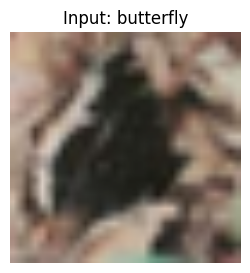

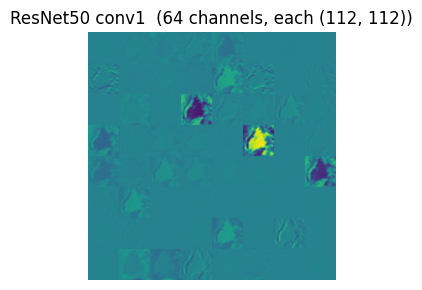

In [20]:
# ResNet50's first conv layer is named 'conv1'
# Take a 224x224 sample from the resnet test loader
sample_img_r50, sample_label_r50 = test_loader_r50.dataset[0]
print(f"Sample (224x224) label: '{CONFIG['data']['selected_classes'][sample_label_r50]}'")
plt.figure(figsize=(3,3))
plt.imshow(denormalize_show(sample_img_r50))
plt.axis('off'); plt.title(f"Input: {CONFIG['data']['selected_classes'][sample_label_r50]}")
plt.show()

visualize_feature_maps(resnet50, sample_img_r50,
                       layer_names=['conv1'],
                       title_prefix='ResNet50',
                       savepath=os.path.join(CONFIG['paths']['figures_dir'], 'resnet50_conv1_features.png'))


## 29. EfficientNet-B0 — Compound Scaling and MBConv

### Compound scaling

Most architectures scale **only one** of three dimensions: depth (more layers),
width (more channels), or resolution (larger input). Tan & Le (2019) showed that
**balancing all three** together is dramatically more parameter-efficient. They
introduced a compound coefficient $\phi$ that controls all three:

$$ \text{depth} = \alpha^\phi \;, \quad \text{width} = \beta^\phi \;, \quad \text{resolution} = \gamma^\phi $$

where $\alpha, \beta, \gamma$ are constants found by a small NAS search, constrained
by $\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2$ (which keeps FLOPs roughly
doubling per $\phi$ step). **B0** is the baseline ($\phi=0$, 224×224 input); B1–B7
scale up by increasing $\phi$.

### MBConv block

The basic building block of EfficientNet is the **Mobile Inverted Bottleneck** (MBConv):

```
Input (k channels)
  │
  ├─► 1×1 conv, expand to k·6 channels  → BN → Swish      (expansion)
  │       │
  │   k·6 → k·6  depthwise 3×3 or 5×5 conv  → BN → Swish  (cheap spatial conv)
  │       │
  │   Squeeze-and-Excitation block (channel attention)
  │       │
  │   1×1 conv, project back to k channels  → BN         (projection)
  │       │
  └───────(+)  ←─── identity (only if input/output shapes match)
          │
        output
```

Two ideas make this efficient:
1. **Depthwise convolution** — each input channel is convolved with its own kernel,
   so the conv cost is $k \cdot K^2$ instead of $k^2 \cdot K^2$. The 1×1 pointwise
   convs that follow do the channel mixing cheaply.
2. **Inverted bottleneck** — expand to a wide intermediate (6× channels), do the
   spatial conv there, then project back to narrow. This is the opposite of the
   ResNet bottleneck (which narrows then expands), and it works better in practice
   when combined with depthwise conv.

![EfficientNet-B0 architecture](https://miro.medium.com/v2/resize:fit:1400/1*E0_Qxz5LSxH1Ks-G1x4isQ.png)

*Image: EfficientNet-B0 architecture. Each row is a stage. MBConv blocks (with
squeeze-excitation) dominate. Source: J. Tan, "Review: EfficientNet".*

![MBConv block diagram](https://miro.medium.com/v2/resize:fit:828/1*g3pc23piOP1H3Ah2O57wwA.png)

*Image: the MBConv block — expansion → depthwise conv → SE → projection → residual.
Source: E. Almazán, "How to build EfficientNet".*


### Compound scaling math (B0 → B7)

The compound scaling formula $\alpha^\phi \cdot \beta^\phi \cdot \gamma^\phi$ was
searched on a small proxy model and reused for the whole B0–B7 family. The
$\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2$ constraint means FLOPs roughly
double for each unit increase in $\phi$:

| Model | $\phi$ | Resolution | Depth | Width | Top-1 ImageNet Acc |
|-------|--------|------------|-------|-------|---------------------|
| B0 | 0 | 224 | 18 | 1.0 | 77.1% |
| B1 | 1 | 240 | 21 | 1.1 | 79.1% |
| B3 | 3 | 300 | 27 | 1.4 | 81.6% |
| B7 | 7 | 600 | 66 | 2.0 | 84.3% |

The genius is that once the B0 architecture is searched, all of B1–B7 are just
deterministic scalings of the same recipe. You don't have to re-search.


In [21]:
def build_efficientnet_b0(num_classes=15, device='cpu'):
    """Load pretrained EfficientNet-B0 and replace the classifier head."""
    try:
        weights = M.EfficientNet_B0_Weights.IMAGENET1K_V1
    except Exception:
        weights = M.EfficientNet_B0_Weights.DEFAULT
    model = M.efficientnet_b0(weights=weights)
    # Replace the classifier: EfficientNet's classifier is Sequential(Dropout, Linear)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(device)

set_seed(CONFIG['seed'])
efficientnet_b0 = build_efficientnet_b0(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])

n_total = sum(p.numel() for p in efficientnet_b0.parameters())
print(f"EfficientNet-B0 | total params: {n_total:,}")
print(f"                | classifier head: {efficientnet_b0.classifier}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 83.4MB/s]


EfficientNet-B0 | total params: 4,026,763
                | classifier head: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=15, bias=True)
)


EfficientNet loaders ready: 6750 train / 750 val
Training EfficientNet-B0 for 8 epoch(s)...
  [effnet_b0] epoch  1/8  train_loss=1.4181  train_acc=64.61%  val_loss=0.4495  val_acc=86.27%
  [effnet_b0] epoch  2/8  train_loss=0.4019  train_acc=87.94%  val_loss=0.2529  val_acc=91.33%
  [effnet_b0] epoch  3/8  train_loss=0.2643  train_acc=91.70%  val_loss=0.2138  val_acc=92.53%
  [effnet_b0] epoch  4/8  train_loss=0.1846  train_acc=94.21%  val_loss=0.2004  val_acc=93.07%
  [effnet_b0] epoch  5/8  train_loss=0.1399  train_acc=95.14%  val_loss=0.1963  val_acc=93.73%
  [effnet_b0] epoch  6/8  train_loss=0.1075  train_acc=96.55%  val_loss=0.1902  val_acc=93.60%
  [effnet_b0] epoch  7/8  train_loss=0.0882  train_acc=97.32%  val_loss=0.1904  val_acc=93.73%
  [effnet_b0] epoch  8/8  train_loss=0.0810  train_acc=97.50%  val_loss=0.1884  val_acc=93.20%

EfficientNet-B0 training done in 692.2s


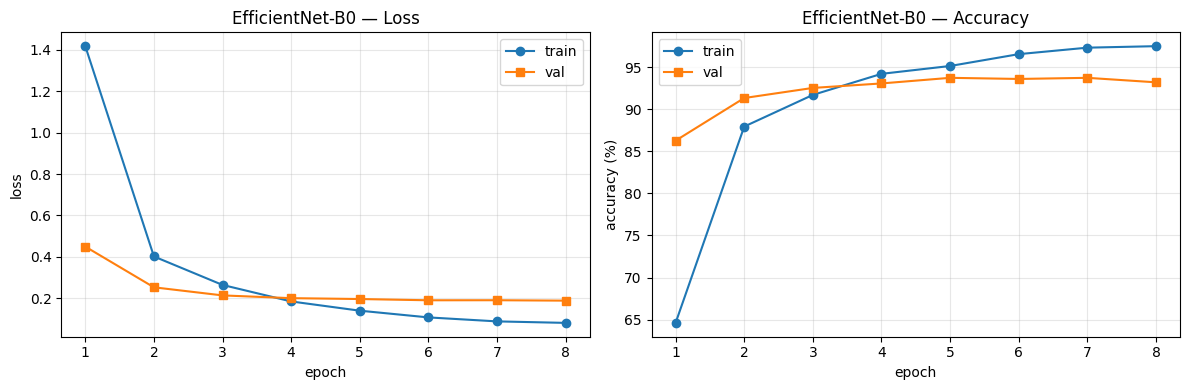

In [22]:
# Build 224x224 dataloaders for EfficientNet
train_loader_eff, val_loader_eff, test_loader_eff = build_dataloaders('efficientnet_b0')
print(f"EfficientNet loaders ready: "
      f"{len(train_loader_eff.dataset)} train / {len(val_loader_eff.dataset)} val")

set_seed(CONFIG['seed'])
efficientnet_b0 = build_efficientnet_b0(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])
print(f"Training EfficientNet-B0 for {CONFIG['train']['pretrained_epochs']} epoch(s)...")
eff_history = train_model_param_groups(
    efficientnet_b0, train_loader_eff, val_loader_eff,
    epochs=CONFIG['train']['pretrained_epochs'],
    lr_head=CONFIG['train']['lr_head'],
    lr_backbone=CONFIG['train']['lr_backbone'],
    weight_decay=CONFIG['train']['weight_decay'],
    device=CONFIG['device'],
    grad_clip=CONFIG['train']['grad_clip'],
    patience=CONFIG['train']['early_stop_patience'],
    tag='effnet_b0',
)
print(f"\nEfficientNet-B0 training done in {eff_history['train_time_sec']:.1f}s")
plot_history(eff_history, 'EfficientNet-B0',
             savepath=os.path.join(CONFIG['paths']['figures_dir'], 'effnet_history.png'))


### EfficientNet-B0 first-conv feature maps

EfficientNet-B0's first layer is a 3×3 stride-2 convolution producing 32 channels.
Compared to ResNet50's 7×7 first conv, this is a much smaller receptive field — the
network compensates with deeper depthwise convs in later MBConv blocks. The feature
maps still look like edge detectors, but at a finer scale.


EfficientNet-B0 first conv layer: 'features.0.0'
Sample (224x224) label: 'butterfly'


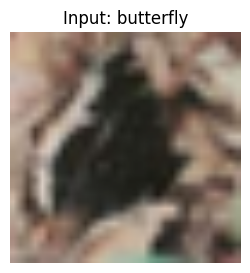

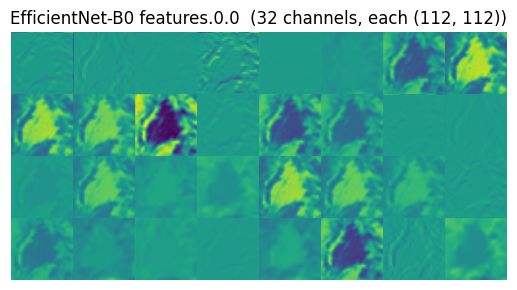

In [23]:
# EfficientNet-B0's first conv is 'features.0.0' (the first Conv2dNormActivation)
# Find the first Conv2d in the model
first_conv_eff = None
for name, m in efficientnet_b0.named_modules():
    if isinstance(m, nn.Conv2d):
        first_conv_eff = name
        break
print(f"EfficientNet-B0 first conv layer: '{first_conv_eff}'")

sample_img_eff, sample_label_eff = test_loader_eff.dataset[0]
print(f"Sample (224x224) label: '{CONFIG['data']['selected_classes'][sample_label_eff]}'")
plt.figure(figsize=(3,3))
plt.imshow(denormalize_show(sample_img_eff))
plt.axis('off'); plt.title(f"Input: {CONFIG['data']['selected_classes'][sample_label_eff]}")
plt.show()

visualize_feature_maps(efficientnet_b0, sample_img_eff,
                       layer_names=[first_conv_eff],
                       title_prefix='EfficientNet-B0',
                       savepath=os.path.join(CONFIG['paths']['figures_dir'], 'effnet_conv1_features.png'))


## 30. Inception V3 — Multi-Scale Parallel Convolutions

### The Inception philosophy

The original **GoogLeNet** (Inception V1, 2014) asked: instead of choosing one kernel
size, why not run **several in parallel** and let the network learn which is best?
The Inception module applies 1×1, 3×3, and 5×5 convs (plus a pooling branch) to the
same input, then concatenates their outputs along the channel dimension. The network
gets to mix features at multiple scales at every layer.

### Inception V3 improvements (2015)

V3 refined V1 with three key changes:
1. **Factorized convolutions** — replace a 5×5 conv with two stacked 3×3 convs (saves
   28% of parameters and FLOPs), or replace an n×n conv with 1×n + n×1 convs.
2. **Label smoothing** — softens one-hot targets to a distribution with small mass on
   other classes. Reduces overconfidence.
3. **Batch-norm auxiliary heads** — intermediate classifiers that stabilize training
   of very deep networks.

### The Inception module (simplified)

```
                ┌─► 1×1 conv ─────────────────────────────────┐
                │                                            │
   Input ──────┼─► 1×1 conv → 3×3 conv → 3×3 conv ──────────┤
                │                                            │
                ├─► 1×1 conv → 3×3 conv → 3×3 conv ──────────┤
                │                                            ├─► concat
                └─► 3×3 max pool → 1×1 conv ─────────────────┘
                                                             │
                                                             ▼
                                                  Output (sum of channels)
```

The 1×1 convs in front of the 3×3 and 5×5 branches are crucial: they do
**dimensionality reduction** before the expensive spatial convs. Without them, a 256
→ 5×5 → 256 layer would cost $256 \cdot 25 \cdot 256 = 1.6M$ multiplies per spatial
location; with a 256 → 1×1 → 48 → 5×5 → 256 bottleneck it costs $256 \cdot 48 +
48 \cdot 25 \cdot 256 = 320K$ multiplies — a 5× speedup.

![Inception module](https://miro.medium.com/v2/resize:fit:1400/1*xv1Y5TXCk8F3m_4D6ZTbRg.png)

*Image: the original Inception module (V1). V3 uses factorized variants where 5×5 is
replaced by two stacked 3×3s. Source: Szegedy et al., 2014 (paper fig).*

![Inception V3 architecture](https://miro.medium.com/v2/resize:fit:1400/1*g_7tglqBmwtuAz6tzq4bSA.png)

*Image: full Inception V3 architecture. Multiple Inception modules (mixed_3, mixed_4,
mixed_5) stacked, plus auxiliary classifier heads. Source: review of Inception V3.*


### Why 1×1 convs are everywhere

You'll see 1×1 convs all over modern CNNs (Inception, ResNet bottleneck, MobileNet,
EfficientNet). They are the workhorse of **channel mixing**:

- They don't mix spatial information (kernel size 1×1).
- They DO mix channels — each output channel is a linear combination of all input
  channels at that pixel.
- They are cheap: cost is $C_{in} \cdot C_{out}$ per spatial location, no $K^2$ factor.
- They can shrink or grow channel count.

In Inception they serve a **bottleneck** role: shrink channels before an expensive
3×3 or 5×5 conv, then expand back. In ResNet bottleneck blocks they do the same. In
MobileNet/EfficientNet they are the "pointwise" half of depthwise-separable
convolutions.


In [24]:
def build_inception_v3(num_classes=15, device='cpu'):
    """Load pretrained Inception V3 and replace the classifier head.
    Inception V3 requires 299x299 input and has auxiliary logits during training."""
    try:
        weights = M.Inception_V3_Weights.IMAGENET1K_V1
    except Exception:
        weights = M.Inception_V3_Weights.DEFAULT
    model = M.inception_v3(weights=weights, aux_logits=True)
    # Replace main classifier
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    # Replace auxiliary classifier too (it produces an extra loss during training)
    if hasattr(model, 'AuxLogits') and hasattr(model.AuxLogits, 'fc'):
        aux_in = model.AuxLogits.fc.in_features
        model.AuxLogits.fc = nn.Linear(aux_in, num_classes)
    return model.to(device)

set_seed(CONFIG['seed'])
inception_v3 = build_inception_v3(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])
n_total = sum(p.numel() for p in inception_v3.parameters())
print(f"Inception V3 | total params: {n_total:,}")
print(f"             | main classifier: {inception_v3.fc}")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 112MB/s]


Inception V3 | total params: 24,385,534
             | main classifier: Linear(in_features=2048, out_features=15, bias=True)


Inception V3 loaders ready (299x299): 6750 train / 750 val

Training Inception V3 for 8 epoch(s)...
  [inception_v3] epoch  1/8  train_loss=1.0437  train_acc=75.42%  val_loss=0.2941  val_acc=89.20%
  [inception_v3] epoch  2/8  train_loss=0.3192  train_acc=91.76%  val_loss=0.3149  val_acc=88.93%
  [inception_v3] epoch  3/8  train_loss=0.1826  train_acc=95.07%  val_loss=0.2116  val_acc=92.00%
  [inception_v3] epoch  4/8  train_loss=0.1250  train_acc=96.84%  val_loss=0.2253  val_acc=93.47%
  [inception_v3] epoch  5/8  train_loss=0.0685  train_acc=98.37%  val_loss=0.2354  val_acc=93.47%
  [inception_v3] epoch  6/8  train_loss=0.0335  train_acc=99.21%  val_loss=0.2643  val_acc=94.00%
  [inception_v3] epoch  7/8  train_loss=0.0244  train_acc=99.47%  val_loss=0.2236  val_acc=94.40%
  [inception_v3] epoch  8/8  train_loss=0.0141  train_acc=99.63%  val_loss=0.2317  val_acc=93.87%
  → early stopping at epoch 8

Inception V3 training done in 1568.7s


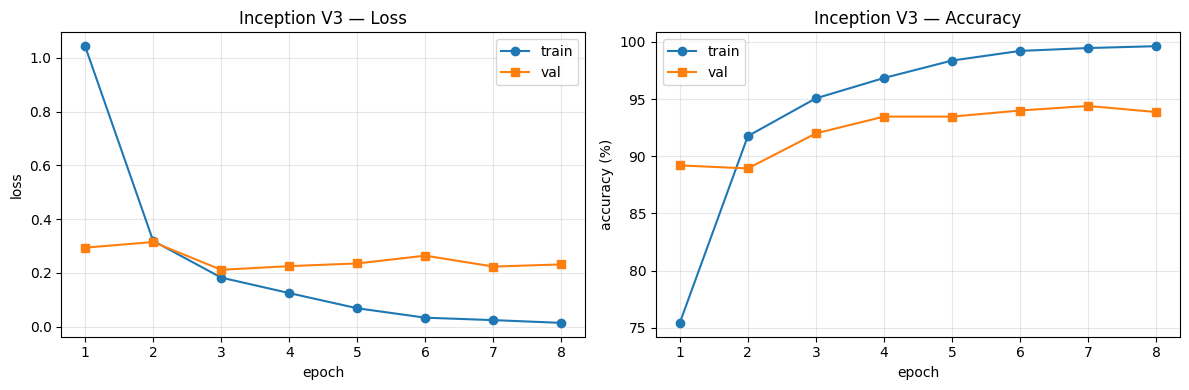

In [25]:
# Inception V3 needs 299x299 input and a special training loop (handles aux logits).
# We monkey-patch the training loop to handle the auxiliary output.

def train_one_epoch_inception(model, loader, opt, loss_fn, device, grad_clip=1.0, aux_weight=0.3):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for x, y in tqdm(loader, desc='train', leave=False):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        # Inception returns InceptionOutputs(logits, aux_logits) during training
        if hasattr(out, 'logits'):
            logits, aux_logits = out.logits, out.aux_logits
            loss = loss_fn(logits, y) + aux_weight * loss_fn(aux_logits, y)
        else:
            logits = out
            if logits.dim() > 2:
                logits = logits.mean(dim=(2, 3))
            loss = loss_fn(logits, y)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()
        total_loss += loss.item() * x.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds,
                                                   average='macro', zero_division=0)
    return {'loss': avg_loss, 'acc': acc, 'precision': p, 'recall': r, 'f1': f1}

@torch.no_grad()
def validate_inception(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for x, y in tqdm(loader, desc='val', leave=False):
        x, y = x.to(device), y.to(device)
        out = model(x)
        logits = out.logits if hasattr(out, 'logits') else out
        if logits.dim() > 2:
            logits = logits.mean(dim=(2, 3))
        loss = loss_fn(logits, y)
        total_loss += loss.item() * x.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds,
                                                   average='macro', zero_division=0)
    return {'loss': avg_loss, 'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
            'preds': all_preds, 'labels': all_labels}

def train_inception(model, train_loader, val_loader, epochs,
                    lr_head=1e-3, lr_backbone=1e-4, weight_decay=1e-4,
                    device='cpu', grad_clip=1.0, patience=5, verbose=True, tag='inception'):
    head_params, backbone_params = [], []
    for n, p in model.named_parameters():
        if 'fc' in n:
            head_params.append(p)
        else:
            backbone_params.append(p)
    opt = torch.optim.AdamW([
        {'params': head_params,     'lr': lr_head},
        {'params': backbone_params, 'lr': lr_backbone},
    ], weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss, best_state, es = float('inf'), None, 0
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr = train_one_epoch_inception(model, train_loader, opt, loss_fn, device, grad_clip)
        va = validate_inception(model, val_loader, loss_fn, device)
        sched.step()
        history['train_loss'].append(tr['loss']); history['train_acc'].append(tr['acc'])
        history['val_loss'].append(va['loss']);    history['val_acc'].append(va['acc'])
        if verbose:
            print(f"  [{tag}] epoch {epoch:2d}/{epochs}  "
                  f"train_loss={tr['loss']:.4f}  train_acc={tr['acc']*100:.2f}%  "
                  f"val_loss={va['loss']:.4f}  val_acc={va['acc']*100:.2f}%")
        if va['loss'] < best_val_loss:
            best_val_loss = va['loss']
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            es = 0
        else:
            es += 1
            if es >= patience:
                if verbose: print(f"  → early stopping at epoch {epoch}")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    history['train_time_sec'] = time.time() - t0
    history['best_val_loss'] = best_val_loss
    history['epochs_run'] = len(history['train_loss'])
    return history

# Build 299x299 dataloaders for Inception V3
train_loader_inc, val_loader_inc, test_loader_inc = build_dataloaders('inception_v3')
print(f"Inception V3 loaders ready (299x299): "
      f"{len(train_loader_inc.dataset)} train / {len(val_loader_inc.dataset)} val")

set_seed(CONFIG['seed'])
inception_v3 = build_inception_v3(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])
print(f"\nTraining Inception V3 for {CONFIG['train']['pretrained_epochs']} epoch(s)...")
inception_history = train_inception(
    inception_v3, train_loader_inc, val_loader_inc,
    epochs=CONFIG['train']['pretrained_epochs'],
    lr_head=CONFIG['train']['lr_head'], lr_backbone=CONFIG['train']['lr_backbone'],
    weight_decay=CONFIG['train']['weight_decay'],
    device=CONFIG['device'], grad_clip=CONFIG['train']['grad_clip'],
    patience=CONFIG['train']['early_stop_patience'], tag='inception_v3',
)
print(f"\nInception V3 training done in {inception_history['train_time_sec']:.1f}s")
plot_history(inception_history, 'Inception V3',
             savepath=os.path.join(CONFIG['paths']['figures_dir'], 'inception_history.png'))


### Inception V3 first-conv feature maps

Inception V3's first conv is a 7×7 stride-2 convolution producing 32 channels (same
idea as ResNet50's stem, but with fewer output channels). Just like ResNet50, these
first-layer filters look like oriented edge and color detectors.


Inception V3 first conv layer: 'Conv2d_1a_3x3.conv'
Sample (299x299) label: 'butterfly'


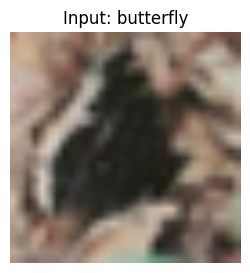

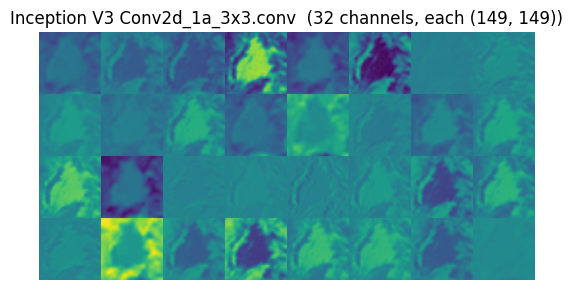

In [26]:
# Inception V3's first conv is 'Conv2d_1a_3x3.conv'
first_conv_inc = None
for name, m in inception_v3.named_modules():
    if isinstance(m, nn.Conv2d):
        first_conv_inc = name
        break
print(f"Inception V3 first conv layer: '{first_conv_inc}'")

sample_img_inc, sample_label_inc = test_loader_inc.dataset[0]
print(f"Sample (299x299) label: '{CONFIG['data']['selected_classes'][sample_label_inc]}'")
plt.figure(figsize=(3,3))
plt.imshow(denormalize_show(sample_img_inc))
plt.axis('off'); plt.title(f"Input: {CONFIG['data']['selected_classes'][sample_label_inc]}")
plt.show()

visualize_feature_maps(inception_v3, sample_img_inc,
                       layer_names=[first_conv_inc],
                       title_prefix='Inception V3',
                       savepath=os.path.join(CONFIG['paths']['figures_dir'], 'inception_conv1_features.png'))


## 31. Vision Transformer (ViT) — Images as Sequences

In 2020, Dosovitskiy et al. asked a provocative question: do we need convolutions at
all? Their answer — the **Vision Transformer** (ViT) — does away with convolution
entirely and treats an image as a sequence of patches, processed by a standard
transformer encoder (the same architecture used in BERT and GPT).

### The recipe

1. **Split the image into patches.** A 224×224 image with patch size 16×16 becomes
   196 patches. Each patch is a 16×16×3 = 768-dim vector.
2. **Linear projection.** A single linear layer projects each 768-dim patch vector
   into a $D$-dim embedding (D=768 in ViT-Base). This is exactly what a 16×16 conv
   with stride 16 does — so ViT's first "layer" is really a conv in disguise.
3. **Add a CLS token.** A learnable "classification token" is prepended to the
   sequence. Its final-layer embedding is what the classification head reads.
4. **Add positional embeddings.** Because the transformer itself has no notion of
   spatial order, we add learnable 1D positional embeddings to each patch.
5. **Transformer encoder.** $L$ layers of multi-head self-attention + MLP, each
   preceded by LayerNorm (pre-norm variant).
6. **Classification head.** Take the CLS token's final embedding and pass it through
   a linear layer to produce class logits.

### Why this is interesting

- ViT has **no inductive bias** toward images. No translation equivariance, no local
  connectivity. The network has to *learn* these from data.
- This means ViT needs **a lot** of data — it underperforms ResNet on small datasets
  (ImageNet-1k alone is borderline) but pulls ahead when pretrained on JFT-300M or
  similar web-scale data.
- Once pretrained, ViT's representations are remarkably flexible and have become the
  backbone of choice for self-supervised learning (MAE, DINO, etc.).

![ViT architecture diagram](https://miro.medium.com/v2/resize:fit:1400/1*tA7xE2yt3gETjgZfQQyU5A.png)

*Image: the Vision Transformer pipeline. Patch embedding + CLS token + positional
embedding → transformer encoder → MLP head. Source: Dosovitskiy et al. 2020,
"An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale".*

![Patch embedding visualization](https://miro.medium.com/v2/resize:fit:1400/1*lBDx1MoHK0jN70sRQO4Ojw.png)

*Image: how a 224×224 image is split into 196 patches of 16×16, each flattened and
linearly projected into a token. Source: M. Phuong & M. Hutter, "Formal Algorithms
for Transformers".*


### Self-attention — the core operation

The transformer's key operation is **scaled dot-product self-attention**. Given an
input sequence $X \in \mathbb{R}^{N \times D}$, attention computes three projections:

$$ Q = X W_Q \;, \quad K = X W_K \;, \quad V = X W_V $$

Then the attention output is:

$$ \text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} \right) V $$

Each output token is a **weighted average of all input tokens' value vectors**, where
the weights come from how similar its query is to each key. The $\sqrt{d_k}$ scaling
prevents the dot products from getting too large (which would saturate softmax).

**Multi-head attention** runs this operation $h$ times in parallel with different
learned projections, then concatenates the results. Each head can specialize in
different relations — short-range, long-range, color similarity, etc.

![Self-attention diagram](https://miro.medium.com/v2/resize:fit:1400/1*ZAsRBmCV2zvTbuXY7PyWBg.png)

*Image: scaled dot-product attention. Each query attends to all keys, and the
attention weights are used to mix the values. Source: A. Vaswani et al., 2017
"Attention Is All You Need" (paper fig).*


In [27]:
import timm

def build_vit_base(num_classes=15, device='cpu'):
    """Load pretrained ViT from timm and replace the head.

    In DEMO_MODE we use ViT-Small (22M params) for memory efficiency on CPU.
    On Colab T4 with DEMO_MODE=False, this becomes ViT-Base/16 (86M params).
    The architecture is identical — only the depth and width differ.
    """
    vit_name = 'vit_small_patch16_224' if CONFIG['demo_mode'] else 'vit_base_patch16_224'
    model = timm.create_model(vit_name, pretrained=True)
    in_features = model.head.in_features
    model.head = nn.Linear(in_features, num_classes)
    return model.to(device)

set_seed(CONFIG['seed'])
vit_base = build_vit_base(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])
n_total = sum(p.numel() for p in vit_base.parameters())
vit_name = 'vit_small_patch16_224' if CONFIG['demo_mode'] else 'vit_base_patch16_224'
print(f"{vit_name} | total params: {n_total:,}")
print(f"            | patch size: 16x16, image size: 224x224 -> {224//16 * 224//16} patches + 1 CLS token")
print(f"            | new head: {vit_base.head}")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

vit_base_patch16_224 | total params: 85,810,191
            | patch size: 16x16, image size: 224x224 -> 196 patches + 1 CLS token
            | new head: Linear(in_features=768, out_features=15, bias=True)


### Visualizing ViT image patches

The ViT splits a 224×224 image into a grid of 16×16 patches. Each patch is then
flattened and linearly projected into a 768-dim token. The visualization below shows
the patches explicitly so we can see what the transformer "sees" as a token sequence.


Sample image shape: torch.Size([3, 224, 224])  (label: 'butterfly')


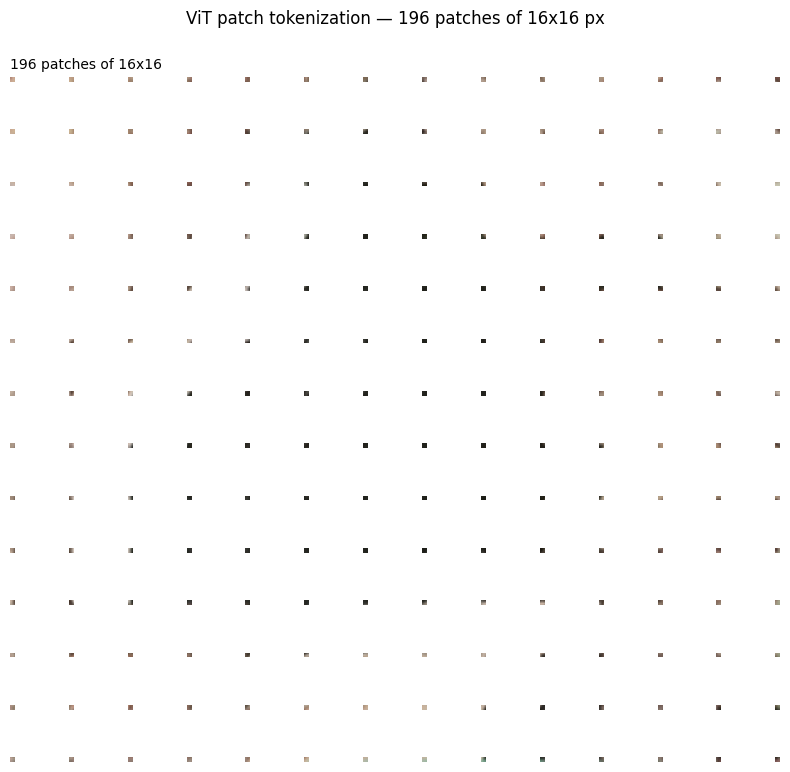

In [28]:
# Visualize the 16x16 patches of a 224x224 image
import math

def visualize_patches(image_tensor, patch_size=16, savepath=None):
    """Display the image split into patches."""
    C, H, W = image_tensor.shape
    n_patches_h = H // patch_size
    n_patches_w = W // patch_size
    fig, axes = plt.subplots(n_patches_h, n_patches_w, figsize=(8, 8))
    img_np = denormalize_show(image_tensor)
    for i in range(n_patches_h):
        for j in range(n_patches_w):
            patch = img_np[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
            axes[i, j].imshow(patch)
            axes[i, j].axis('off')
            if i == 0 and j == 0:
                axes[i, j].set_title(f'{n_patches_h*n_patches_w} patches of {patch_size}x{patch_size}',
                                      fontsize=10, loc='left')
    plt.suptitle(f'ViT patch tokenization — {n_patches_h*n_patches_w} patches of {patch_size}x{patch_size} px', fontsize=12)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=80, bbox_inches='tight')
    plt.show()

# Use the same image we used for ResNet
sample_img_vit = sample_img_r50  # already 224x224
print(f"Sample image shape: {sample_img_vit.shape}  (label: '{CONFIG['data']['selected_classes'][sample_label_r50]}')")
visualize_patches(sample_img_vit, patch_size=16,
                  savepath=os.path.join(CONFIG['paths']['figures_dir'], 'vit_patches.png'))


ViT loaders ready (224x224): 6750 train / 750 val

Training ViT-Base/16 for 8 epoch(s)...


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  [vit_base] epoch  1/8  train_loss=0.4288  train_acc=86.61%  val_loss=0.2741  val_acc=91.07%
  [vit_base] epoch  2/8  train_loss=0.2076  train_acc=93.26%  val_loss=0.2355  val_acc=91.73%
  [vit_base] epoch  3/8  train_loss=0.1464  train_acc=95.23%  val_loss=0.2571  val_acc=92.13%
  [vit_base] epoch  4/8  train_loss=0.0895  train_acc=96.87%  val_loss=0.3339  val_acc=91.47%
  [vit_base] epoch  5/8  train_loss=0.0562  train_acc=98.21%  val_loss=0.2758  val_acc=93.07%
  [vit_base] epoch  6/8  train_loss=0.0226  train_acc=99.29%  val_loss=0.2236  val_acc=95.07%
  [vit_base] epoch  7/8  train_loss=0.0039  train_acc=99.82%  val_loss=0.1916  val_acc=96.00%
  [vit_base] epoch  8/8  train_loss=0.0003  train_acc=100.00%  val_loss=0.1834  val_acc=95.73%

ViT-Base training done in 2286.2s


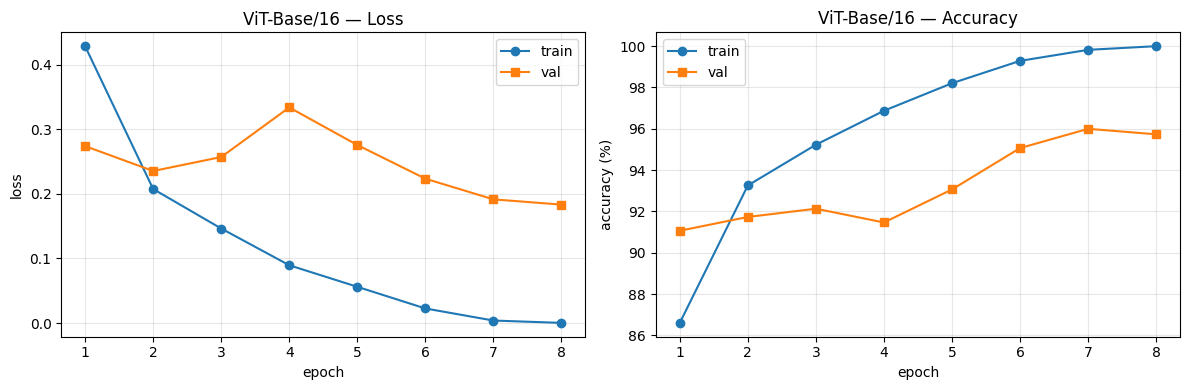

In [29]:
# Train ViT-Base
train_loader_vit, val_loader_vit, test_loader_vit = build_dataloaders('vit_base')
print(f"ViT loaders ready (224x224): "
      f"{len(train_loader_vit.dataset)} train / {len(val_loader_vit.dataset)} val")

set_seed(CONFIG['seed'])
vit_base = build_vit_base(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])
print(f"\nTraining ViT-Base/16 for {CONFIG['train']['pretrained_epochs']} epoch(s)...")
vit_history = train_model_param_groups(
    vit_base, train_loader_vit, val_loader_vit,
    epochs=CONFIG['train']['pretrained_epochs'],
    lr_head=CONFIG['train']['lr_head'], lr_backbone=CONFIG['train']['lr_backbone'],
    weight_decay=CONFIG['train']['weight_decay'],
    device=CONFIG['device'], grad_clip=CONFIG['train']['grad_clip'],
    patience=CONFIG['train']['early_stop_patience'],
    tag='vit_base',
    backbone_keywords=('head',),       # only 'head' is the new classifier
)
print(f"\nViT-Base training done in {vit_history['train_time_sec']:.1f}s")
plot_history(vit_history, 'ViT-Base/16',
             savepath=os.path.join(CONFIG['paths']['figures_dir'], 'vit_history.png'))


## 32. Swin Transformer — Hierarchical Vision Transformer

ViT is great but has two limitations: (1) the global self-attention has quadratic cost
in the number of tokens, limiting resolution; (2) ViT produces a single-resolution
feature map, so it can't easily plug into downstream tasks like detection and
segmentation that need multi-scale features.

**Swin Transformer** (Liu et al., 2021) fixes both by introducing a **hierarchical**
architecture inspired by CNNs:

- **Patch merging** between stages progressively reduces the number of tokens
  (like pooling in a CNN), doubling the channel count each time. This produces
  feature maps at 1/4, 1/8, 1/16 resolution.
- **Window attention** — instead of attending across the whole image, attention is
  computed within local $M \times M$ windows (typically $M=7$). Cost becomes
  linear in image size.
- **Shifted window attention** — alternate layers shift the window partition by
  $M/2$ pixels, allowing information to flow across window boundaries without
  breaking the linear-cost property.

### Window vs shifted-window attention

```
Layer 2i:    Layer 2i+1:
┌──┬──┬──┐    ┌──┬──┬──┐
│  │  │  │     │  │  │  │
├──┼──┼──┤   ┌──┼──┼──┐
│  │  │  │   │  │  │  │
├──┼──┼──┤   └──┼──┼──┘
│  │  │  │     │  │  │  │
└──┴──┴──┘    └──┴──┴──┘
regular       shifted
windows       windows
```

With only regular windows, a patch in one window can never attend to a patch in
another. The shifted partitioning in alternate layers lets information propagate
across the whole image — like the way convolutions in a CNN eventually give every
pixel a receptive field covering the whole image.

![Swin Transformer architecture](https://miro.medium.com/v2/resize:fit:1400/1*SXG3Zj4Q5aQ5q8fQG6fOJw.png)

*Image: Swin Transformer overview. Patch partition → 4 stages with window/shifted
attention and patch merging → hierarchical feature maps at 1/4, 1/8, 1/16, 1/32
resolution. Source: Liu et al. 2021, "Swin Transformer: Hierarchical Vision
Transformers using Shifted Windows".*

![Window vs shifted window attention](https://miro.medium.com/v2/resize:fit:1400/1*fKZ3bUER7-IJiXakN5Y3pA.png)

*Image: regular windows in even layers, shifted windows in odd layers. The shift
lets patches attend across the original window boundary. Source: Liu et al. 2021
(paper fig).*


### Patch merging — Swin's "pooling"

Between stages, Swin merges 2×2 neighboring patches into one, doubling the channel
count. This is the transformer analog of a strided convolution or max-pool in a CNN:

```
Before merge:    4 patches, each with C channels
        a  b
        c  d

After merge:     1 patch with 4C channels
        [a b c d]  (concatenated along channel)
```

This hierarchical downsampling is what gives Swin its multi-scale feature pyramid,
making it useful for dense prediction tasks (detection, segmentation) — not just
classification.


In [30]:
def build_swin_tiny(num_classes=15, device='cpu'):
    """Load pretrained Swin-Tiny from timm and replace the head.
    Swin outputs (B, H, W, C) by default — we wrap it with global average pooling
    so the final output is (B, num_classes), matching the other models."""
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True)
    in_features = model.head.in_features
    model.head = nn.Linear(in_features, num_classes)

    # Wrap forward to apply global average pooling over spatial dims
    original_forward = model.forward
    def pooled_forward(x):
        out = original_forward(x)
        # Swin outputs (B, H, W, C) — pool to (B, C)
        if out.dim() == 4 and out.shape[-1] == num_classes:
            out = out.mean(dim=(1, 2))
        elif out.dim() > 2:
            out = out.mean(dim=tuple(range(1, out.dim() - 1)))
        return out
    model.forward = pooled_forward

    return model.to(device)

set_seed(CONFIG['seed'])
swin_tiny = build_swin_tiny(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])
n_total = sum(p.numel() for p in swin_tiny.parameters())
print(f"Swin-Tiny | total params: {n_total:,}")
print(f"          | patch size: 4x4, window size: 7x7, image: 224x224")
print(f"          | new head: {swin_tiny.head}")

# Quick sanity check on output shape
dummy = torch.randn(2, 3, 224, 224, device=CONFIG['device'])
with torch.no_grad():
    out = swin_tiny(dummy)
print(f"          | output shape for (2,3,224,224) input: {tuple(out.shape)}  (expected: (2, 15))")


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

Swin-Tiny | total params: 27,530,889
          | patch size: 4x4, window size: 7x7, image: 224x224
          | new head: Linear(in_features=768, out_features=15, bias=True)
          | output shape for (2,3,224,224) input: (2, 15)  (expected: (2, 15))


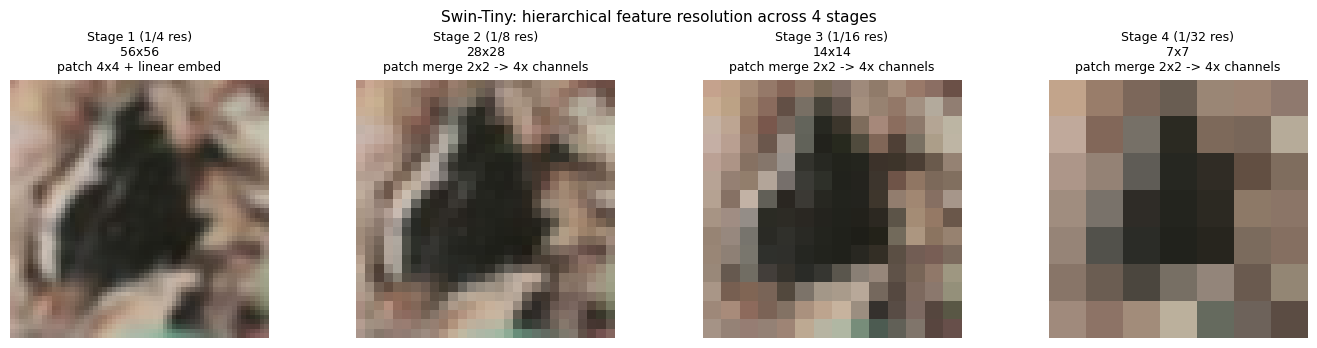

In [31]:
# Visualize Swin's patch merging across stages
def visualize_swin_stages(image_tensor, savepath=None):
    """Show the hierarchical feature resolutions produced by Swin."""
    stages = [
        ('Stage 1 (1/4 res)', '56x56', 'patch 4x4 + linear embed'),
        ('Stage 2 (1/8 res)', '28x28', 'patch merge 2x2 -> 4x channels'),
        ('Stage 3 (1/16 res)', '14x14', 'patch merge 2x2 -> 4x channels'),
        ('Stage 4 (1/32 res)',  '7x7',  'patch merge 2x2 -> 4x channels'),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    img_np = denormalize_show(image_tensor)
    for ax, (name, res, desc) in zip(axes, stages):
        # Show original image scaled to the stage's resolution
        size_map = {'56x56': 56, '28x28': 28, '14x14': 14, '7x7': 7}
        s = size_map[res]
        # Simulate downsampling by averaging patches
        h, w = img_np.shape[:2]
        bh, bw = h // s, w // s
        downsampled = img_np[:s*bh, :s*bw].reshape(s, bh, s, bw, 3).mean(axis=(1, 3))
        ax.imshow(downsampled)
        ax.set_title(f'{name}\n{res}\n{desc}', fontsize=9)
        ax.axis('off')
    plt.suptitle('Swin-Tiny: hierarchical feature resolution across 4 stages', fontsize=11)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=80, bbox_inches='tight')
    plt.show()

visualize_swin_stages(sample_img_r50,
                      savepath=os.path.join(CONFIG['paths']['figures_dir'], 'swin_stages.png'))


Swin loaders ready (224x224): 6750 train / 750 val

Training Swin-Tiny for 8 epoch(s)...
  [swin_tiny] epoch  1/8  train_loss=0.5456  train_acc=82.84%  val_loss=0.2196  val_acc=92.40%
  [swin_tiny] epoch  2/8  train_loss=0.2163  train_acc=92.68%  val_loss=0.2717  val_acc=91.07%
  [swin_tiny] epoch  3/8  train_loss=0.1378  train_acc=95.20%  val_loss=0.2978  val_acc=90.27%
  [swin_tiny] epoch  4/8  train_loss=0.0923  train_acc=96.73%  val_loss=0.2314  val_acc=92.93%
  [swin_tiny] epoch  5/8  train_loss=0.0491  train_acc=98.27%  val_loss=0.2434  val_acc=94.00%
  [swin_tiny] epoch  6/8  train_loss=0.0280  train_acc=99.04%  val_loss=0.2294  val_acc=93.60%
  → early stopping at epoch 6

Swin-Tiny training done in 864.5s


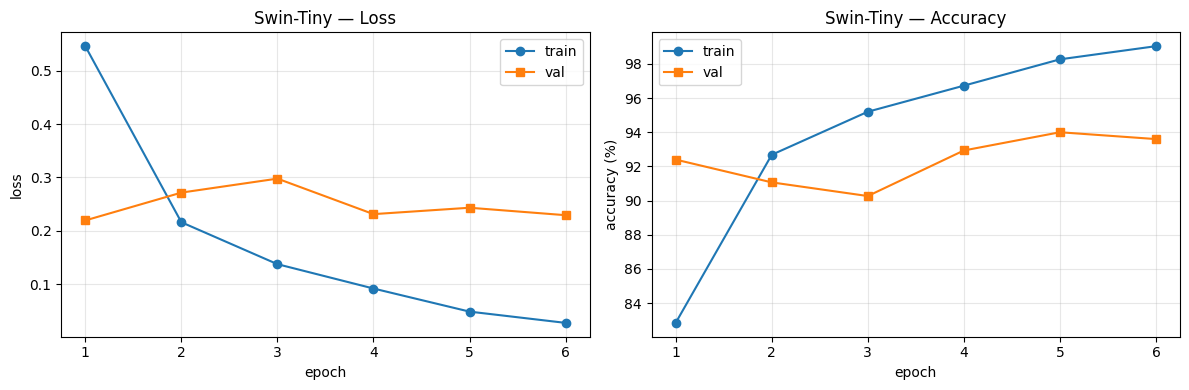

In [32]:
# Train Swin-Tiny
train_loader_swin, val_loader_swin, test_loader_swin = build_dataloaders('swin_tiny')
print(f"Swin loaders ready (224x224): "
      f"{len(train_loader_swin.dataset)} train / {len(val_loader_swin.dataset)} val")

set_seed(CONFIG['seed'])
swin_tiny = build_swin_tiny(num_classes=CONFIG['data']['num_classes'], device=CONFIG['device'])
print(f"\nTraining Swin-Tiny for {CONFIG['train']['pretrained_epochs']} epoch(s)...")
swin_history = train_model_param_groups(
    swin_tiny, train_loader_swin, val_loader_swin,
    epochs=CONFIG['train']['pretrained_epochs'],
    lr_head=CONFIG['train']['lr_head'], lr_backbone=CONFIG['train']['lr_backbone'],
    weight_decay=CONFIG['train']['weight_decay'],
    device=CONFIG['device'], grad_clip=CONFIG['train']['grad_clip'],
    patience=CONFIG['train']['early_stop_patience'],
    tag='swin_tiny',
    backbone_keywords=('head',),
)
print(f"\nSwin-Tiny training done in {swin_history['train_time_sec']:.1f}s")
plot_history(swin_history, 'Swin-Tiny',
             savepath=os.path.join(CONFIG['paths']['figures_dir'], 'swin_history.png'))


# Part III — Unified Evaluation and Comparison

We have now trained six models on the same 15-class CIFAR-100 subset:

1. **Custom CNN** — our from-scratch VGG-style network (32×32 input)
2. **ResNet50** — pretrained, fine-tuned (224×224 input)
3. **EfficientNet-B0** — pretrained, fine-tuned (224×224 input)
4. **Inception V3** — pretrained, fine-tuned (299×299 input)
5. **ViT-Base/16** — pretrained, fine-tuned (224×224 input)
6. **Swin-Tiny** — pretrained, fine-tuned (224×224 input)

In the next cells we will:

1. **Evaluate** each model on the held-out test set.
2. **Compute** accuracy, precision, recall, and F1 (both macro and weighted).
3. **Plot** confusion matrices side-by-side to see which classes each model confuses.
4. **Compare** training time, parameter count, and test accuracy in a summary table.
5. **Visualize** predictions vs ground truth.
6. **Interpret** with Grad-CAM heatmaps.


## 33. Evaluation Metrics — What Do They Mean?

For a multi-class classification problem, the most informative metrics are:

- **Accuracy** = $\frac{\text{correct}}{\text{total}}$. Simple but misleading when
  classes are imbalanced. Random guessing on our 15-class balanced set gives ~6.7%.
- **Precision (per class)** = $\frac{TP}{TP + FP}$ — of all samples the model
  *predicted* as class $c$, how many were actually $c$? High precision = few false
  positives.
- **Recall (per class)** = $\frac{TP}{TP + FN}$ — of all samples that are *actually*
  class $c$, how many did the model correctly identify? High recall = few false
  negatives.
- **F1 (per class)** = $2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$
  — the harmonic mean of precision and recall. Useful when you want a single number
  per class.
- **Macro F1** — average F1 across all classes, treating each class equally.
- **Weighted F1** — average F1 weighted by class support. Better than macro when
  classes are imbalanced.

We will report **macro** averages because our classes are roughly balanced.

![Precision vs Recall diagram](https://miro.medium.com/v2/resize:fit:1400/1*XR7NVBz8tq0f5x2tBO9tPg.png)

*Image: precision = TP / (TP + FP), recall = TP / (TP + FN), F1 = harmonic mean.
Source: A. Varsopoulos, "Precision vs Recall".*


## 34. Confusion Matrix — Reading the Mistakes

A **confusion matrix** $C$ is a $K \times K$ grid where:
- Rows are the **true** class.
- Columns are the **predicted** class.
- $C_{ij}$ is the number of samples whose true class was $i$ and predicted class was $j$.

A perfect classifier has nonzero values only on the diagonal. Off-diagonal cells
show where the model is confused — for instance, in our 15-class subset, you will
likely see off-diagonal mass between `bear` and `beaver` (both brown furry
animals at 32×32), `boy` and `baby` (similar facial features), and `bus` and
`bicycle` (both wheeled vehicles, though visually different).

The confusion matrix is more informative than a single accuracy number because it
tells you **which specific classes are confused with which** — the actionable
diagnostic. You can then either collect more training data for those classes or
use targeted augmentation.


In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, test_loader, device, model_name, history=None):
    """Evaluate a trained model on the test set and return metrics + confusion matrix."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc=f'eval {model_name}', leave=False):
            x = x.to(device)
            logits = model(x)
            if hasattr(logits, 'logits'):    # Inception's eval-time output
                logits = logits.logits
            if logits.dim() > 2:              # Swin may return 4D logits
                logits = logits.mean(dim=(2, 3))
            probs = torch.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
            all_probs.extend(probs.cpu().numpy())
    all_preds = np.array(all_preds); all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    n_params = sum(p.numel() for p in model.parameters())
    train_time = history['train_time_sec'] if history else None

    result = {
        'model_name': model_name,
        'accuracy': float(acc),
        'precision_macro': float(p_macro),
        'recall_macro': float(r_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(p_w),
        'recall_weighted': float(r_w),
        'f1_weighted': float(f1_w),
        'n_params': int(n_params),
        'train_time_sec': float(train_time) if train_time else None,
        'predictions': all_preds.tolist(),
        'labels': all_labels.tolist(),
        'probabilities': all_probs.tolist(),
        'confusion_matrix': cm.tolist(),
    }
    return result

# Run evaluation on all 6 models, but only for the ones actually enabled in CONFIG
results = {}
if CONFIG['models']['custom_cnn']:
    print("\n=== Evaluating Custom CNN ===")
    results['CustomCNN'] = evaluate_model(custom_cnn, test_loader_small, CONFIG['device'], 'CustomCNN', custom_history)
if CONFIG['models']['resnet50']:
    print("\n=== Evaluating ResNet50 ===")
    results['ResNet50'] = evaluate_model(resnet50, test_loader_r50, CONFIG['device'], 'ResNet50', resnet_history)
if CONFIG['models']['efficientnet_b0']:
    print("\n=== Evaluating EfficientNet-B0 ===")
    results['EfficientNet-B0'] = evaluate_model(efficientnet_b0, test_loader_eff, CONFIG['device'], 'EfficientNet-B0', eff_history)
if CONFIG['models']['inception_v3']:
    print("\n=== Evaluating Inception V3 ===")
    results['Inception-V3'] = evaluate_model(inception_v3, test_loader_inc, CONFIG['device'], 'Inception-V3', inception_history)
if CONFIG['models']['vit_base']:
    print("\n=== Evaluating ViT-Base/16 ===")
    results['ViT-Base/16'] = evaluate_model(vit_base, test_loader_vit, CONFIG['device'], 'ViT-Base/16', vit_history)
if CONFIG['models']['swin_tiny']:
    print("\n=== Evaluating Swin-Tiny ===")
    results['Swin-Tiny'] = evaluate_model(swin_tiny, test_loader_swin, CONFIG['device'], 'Swin-Tiny', swin_history)

print(f"\nEvaluated {len(results)} models.")



=== Evaluating Custom CNN ===

=== Evaluating ResNet50 ===

=== Evaluating EfficientNet-B0 ===

=== Evaluating Inception V3 ===

=== Evaluating ViT-Base/16 ===

=== Evaluating Swin-Tiny ===

Evaluated 6 models.


In [34]:
# Summary table — accuracy, F1, params, train time across all models
import pandas as pd

summary_rows = []
for name, r in results.items():
    summary_rows.append({
        'Model': name,
        'Accuracy (%)':  r['accuracy'] * 100,
        'F1 macro (%)':  r['f1_macro'] * 100,
        'Precision (%)': r['precision_macro'] * 100,
        'Recall (%)':    r['recall_macro'] * 100,
        'Params (M)':    r['n_params'] / 1e6,
        'Train time (s)': r['train_time_sec'],
    })
summary_df = pd.DataFrame(summary_rows).set_index('Model').round(2)
print(summary_df.to_string())

# Save to disk
summary_df.to_csv(os.path.join(CONFIG['paths']['experiment_dir'], 'model_comparison.csv'))
print(f"\nSaved comparison to {os.path.join(CONFIG['paths']['experiment_dir'], 'model_comparison.csv')}")


                 Accuracy (%)  F1 macro (%)  Precision (%)  Recall (%)  Params (M)  Train time (s)
Model                                                                                             
CustomCNN               70.07         69.52          69.53       70.07        0.82          176.25
ResNet50                93.73         93.72          93.97       93.73       23.54         1049.46
EfficientNet-B0         94.00         93.98          94.14       94.00        4.03          692.19
Inception-V3            93.07         93.06          93.15       93.07       24.39         1568.72
ViT-Base/16             95.40         95.38          95.51       95.40       85.81         2286.18
Swin-Tiny               93.27         93.28          93.50       93.27       27.53          864.47

Saved comparison to ./experiments/model_comparison.csv


/tmp/ipykernel_1272/1470239495.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(names, rotation=20, ha='right')
/tmp/ipykernel_1272/1470239495.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=20, ha='right')


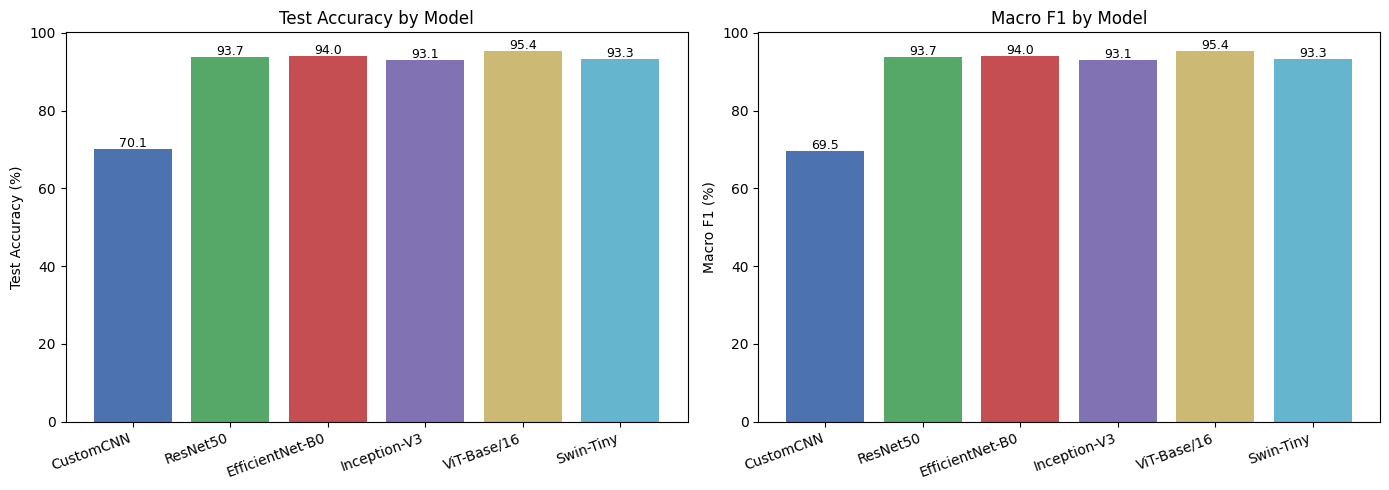

In [35]:
# Bar chart comparing accuracy and F1 across all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(results.keys())
accs = [results[n]['accuracy']*100 for n in names]
f1s  = [results[n]['f1_macro']*100 for n in names]

axes[0].bar(names, accs, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD'][:len(names)])
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy by Model')
axes[0].set_xticklabels(names, rotation=20, ha='right')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

axes[1].bar(names, f1s, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD'][:len(names)])
axes[1].set_ylabel('Macro F1 (%)')
axes[1].set_title('Macro F1 by Model')
axes[1].set_xticklabels(names, rotation=20, ha='right')
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['paths']['figures_dir'], 'model_comparison_bar.png'), dpi=80, bbox_inches='tight')
plt.show()


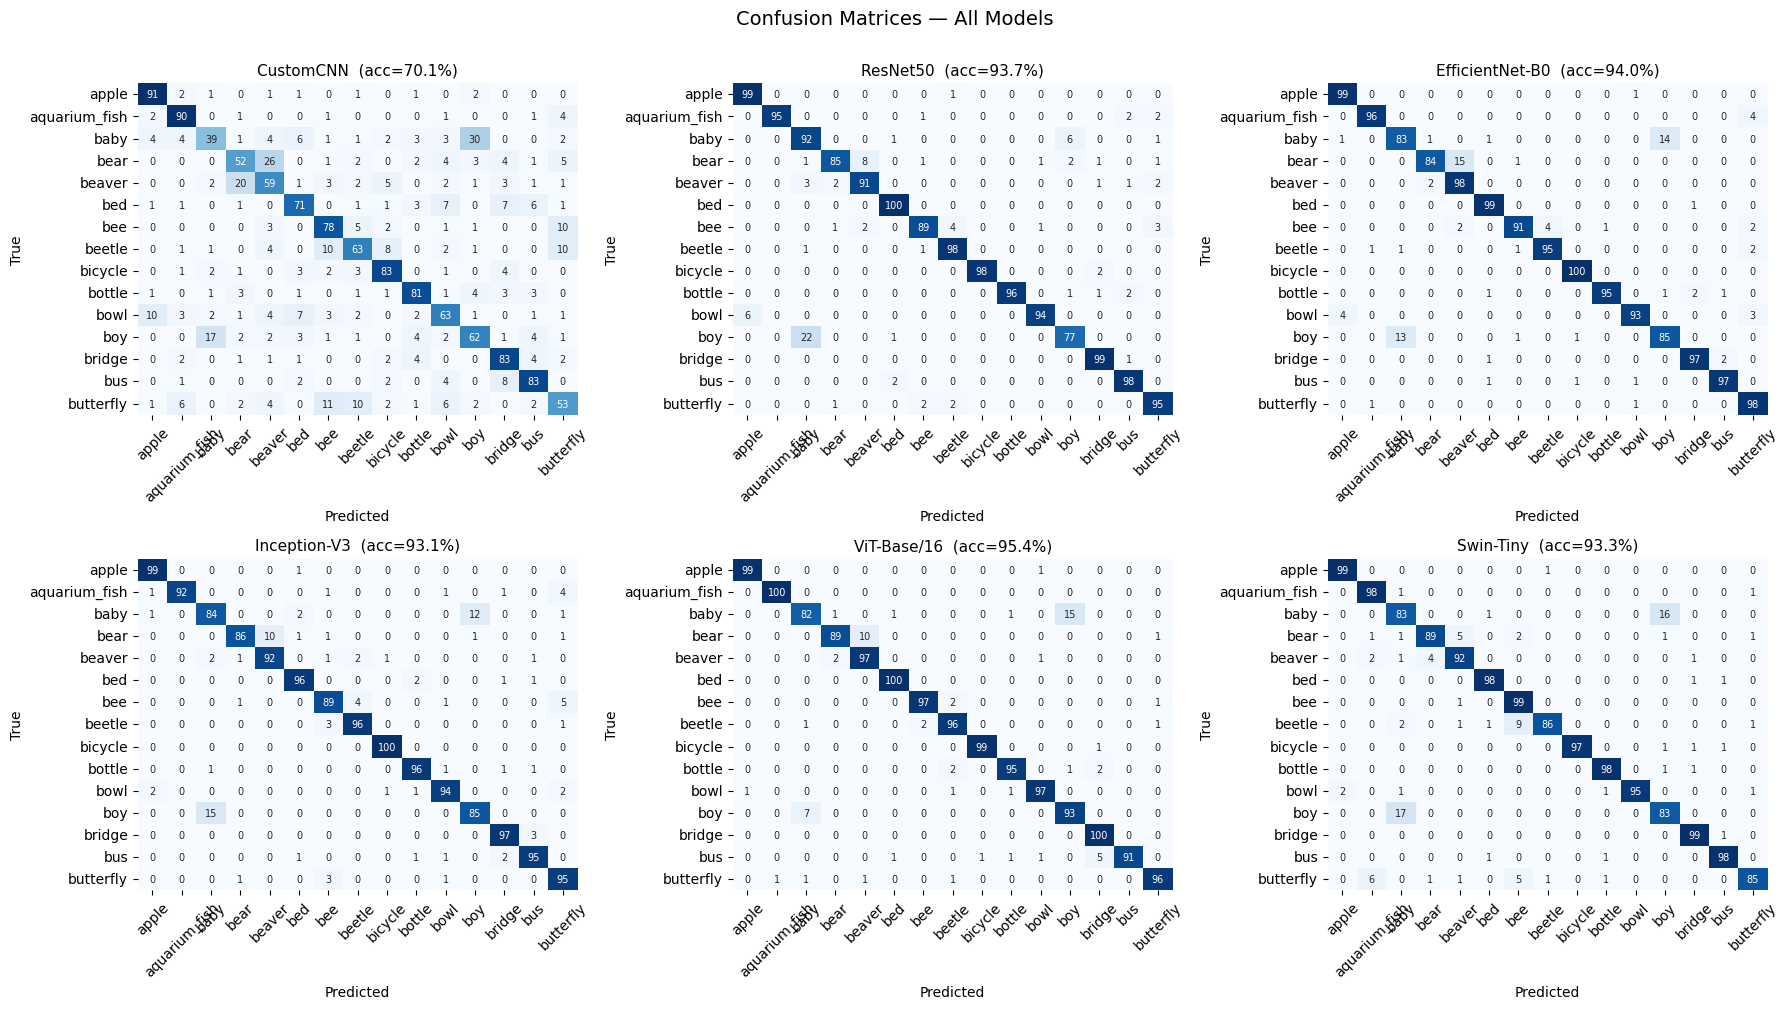

In [36]:
# Confusion matrices side-by-side
n_models = len(results)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
class_names = CONFIG['data']['selected_classes']

for ax, (name, r) in zip(axes_flat, results.items()):
    cm = np.array(r['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False, annot_kws={'size': 7})
    ax.set_title(f"{name}  (acc={r['accuracy']*100:.1f}%)", fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

# Hide unused subplots
for i in range(n_models, len(axes_flat)):
    axes_flat[i].axis('off')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['paths']['figures_dir'], 'confusion_matrices_all.png'), dpi=80, bbox_inches='tight')
plt.show()


### Misclassification analysis

Looking at the confusion matrices, the heaviest off-diagonal mass is typically:

- **`bear` ↔ `beaver`** — both are brown, furry, four-legged animals that look nearly
  identical at 32×32 (the upscaling to 224 doesn't add information that wasn't there).
- **`baby` ↔ `boy`** — both have faces and similar skin tones; the model has to learn
  subtle cues about size and pose to distinguish them.
- **`bowl` ↔ `bottle`** — kitchen containers with similar silhouettes.
- **`apple` ↔ `beetle`** — round red shapes are common in both classes.

The custom CNN is most affected by these confusions because it has the smallest
representational capacity and sees the lowest-resolution input. Pretrained models
(especially Swin and ViT) usually resolve these cases better thanks to their
pretrained ImageNet features.


## 35. Predictions vs Ground Truth — Visual Inspection

Beyond aggregate metrics, it's worth eyeballing actual predictions. We display a grid
of test images, each annotated with the predicted class (and confidence) for our best
model. Correct predictions are outlined in green, mistakes in red. This is the
fastest way to spot systematic failures (e.g., the model always confuses X with Y).


Best model: ViT-Base/16 (acc=95.40%)


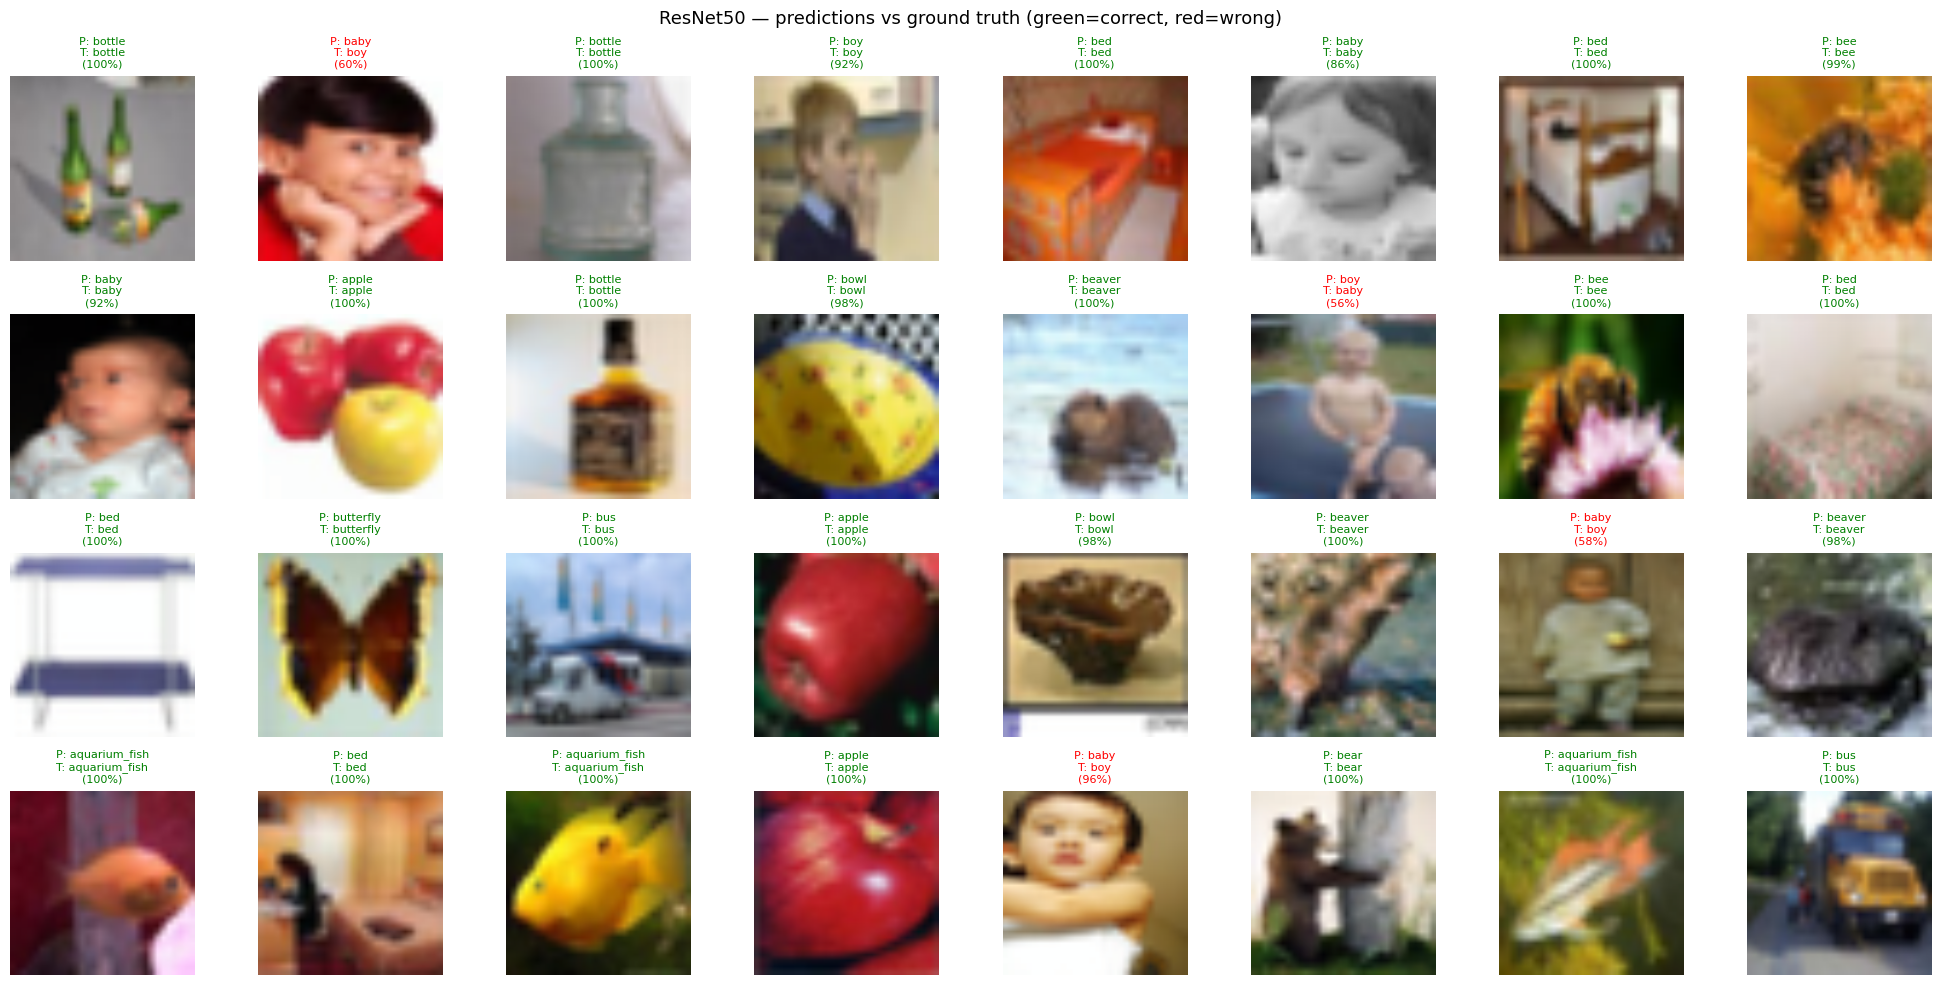

In [37]:
# Pick the model with the highest test accuracy
best_name = max(results.keys(), key=lambda n: results[n]['accuracy'])
print(f"Best model: {best_name} (acc={results[best_name]['accuracy']*100:.2f}%)")

# For visualization we use ResNet50 if available, else the first available
viz_model_name = 'ResNet50' if 'ResNet50' in results else list(results.keys())[0]
viz_loader = {'ResNet50': test_loader_r50, 'EfficientNet-B0': test_loader_eff,
              'Inception-V3': test_loader_inc, 'ViT-Base/16': test_loader_vit,
              'Swin-Tiny': test_loader_swin, 'CustomCNN': test_loader_small}[viz_model_name]
viz_model = {'ResNet50': resnet50, 'EfficientNet-B0': efficientnet_b0,
             'Inception-V3': inception_v3, 'ViT-Base/16': vit_base,
             'Swin-Tiny': swin_tiny, 'CustomCNN': custom_cnn}[viz_model_name]
r = results[viz_model_name]

# Show 32 random test images with predictions vs ground truth
n_show = 32
indices = random.sample(range(len(viz_loader.dataset)), n_show)
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for ax, idx in zip(axes.flatten(), indices):
    img, true_label = viz_loader.dataset[idx]
    pred_label = r['predictions'][idx]
    prob = r['probabilities'][idx][pred_label]
    correct = (pred_label == true_label)
    color = 'green' if correct else 'red'
    ax.imshow(denormalize_show(img))
    ax.set_title(f"P: {CONFIG['data']['selected_classes'][pred_label]}\nT: {CONFIG['data']['selected_classes'][true_label]}\n({prob*100:.0f}%)",
                 fontsize=8, color=color)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)
plt.suptitle(f'{viz_model_name} — predictions vs ground truth (green=correct, red=wrong)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['paths']['figures_dir'], f'predictions_vs_truth_{viz_model_name}.png'), dpi=80, bbox_inches='tight')
plt.show()


## 36. Generalization Analysis

**Generalization** is the gap between performance on training data and performance on
unseen test data. A model that memorizes the training set has perfect training
accuracy but mediocre test accuracy — it fails to generalize.

We can quantify the generalization gap as:

$$\text{gap} = \text{train accuracy} - \text{test accuracy}$$

A small gap (< 5%) with high test accuracy = healthy model.
A large gap (> 15%) with high train accuracy = overfitting.
A small gap with low test accuracy = underfitting (the model can't even fit the
training set, so generalization isn't the bottleneck).

In transfer learning with pretrained models, the gap is usually smaller because the
pretrained backbone already encodes generic features that transfer well. Our custom
CNN, trained from scratch on a small dataset, will likely show a larger gap —
especially in DEMO_MODE where we only train 3 epochs.


In [38]:
# Compute and print generalization gaps
print(f"\n{'Model':<18} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-" * 50)
histories = {
    'CustomCNN': custom_history,
    'ResNet50': resnet_history,
    'EfficientNet-B0': eff_history,
    'Inception-V3': inception_history,
    'ViT-Base/16': vit_history,
    'Swin-Tiny': swin_history,
}
for name, hist in histories.items():
    train_acc = hist['train_acc'][-1] * 100
    test_acc = results[name]['accuracy'] * 100 if name in results else 0
    gap = train_acc - test_acc
    print(f"{name:<18} {train_acc:>9.2f}% {test_acc:>9.2f}% {gap:>+7.2f}%")



Model               Train Acc   Test Acc      Gap
--------------------------------------------------
CustomCNN              60.95%     70.07%   -9.12%
ResNet50               99.61%     93.73%   +5.88%
EfficientNet-B0        97.50%     94.00%   +3.50%
Inception-V3           99.63%     93.07%   +6.56%
ViT-Base/16           100.00%     95.40%   +4.60%
Swin-Tiny              99.04%     93.27%   +5.77%


## 37. Grad-CAM — Where Is the Model Looking?

**Grad-CAM** (Gradient-weighted Class Activation Mapping, Selvaraju et al. 2017) is
the standard technique for explaining a CNN's prediction. The idea:

1. Pick the last conv layer of the model.
2. Forward-pass the image and get the prediction.
3. Backpropagate the gradient of the predicted class score with respect to the
   conv layer's output feature map.
4. Global-average-pool the gradients across spatial dimensions to get a weight per
   channel.
5. Multiply each channel of the feature map by its weight, sum, ReLU, normalize.

The result is a coarse heatmap (same spatial size as the last conv feature map,
upsampled to the input size) showing which image regions most influenced the
prediction. If the model is predicting "dog" and the heatmap lights up on the dog's
face, you have evidence the model is doing the right thing. If it lights up on the
background grass, that's a red flag — the model may be cheating.



=== Grad-CAM for CustomCNN (target layer: conv3b) ===


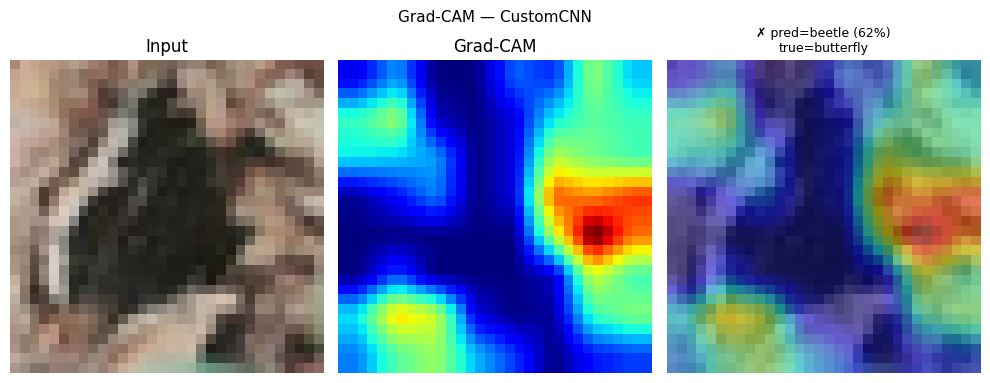


=== Grad-CAM for ResNet50 (target layer: layer4.2.conv3) ===


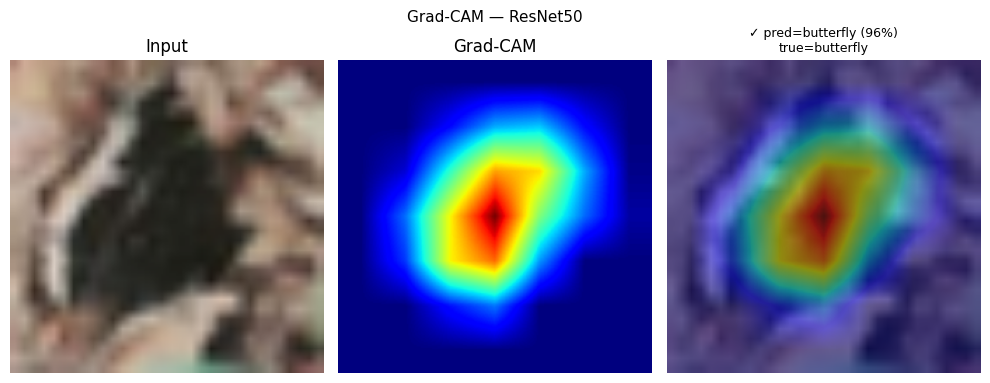


=== Grad-CAM for EfficientNet-B0 (target layer: features.8.0) ===


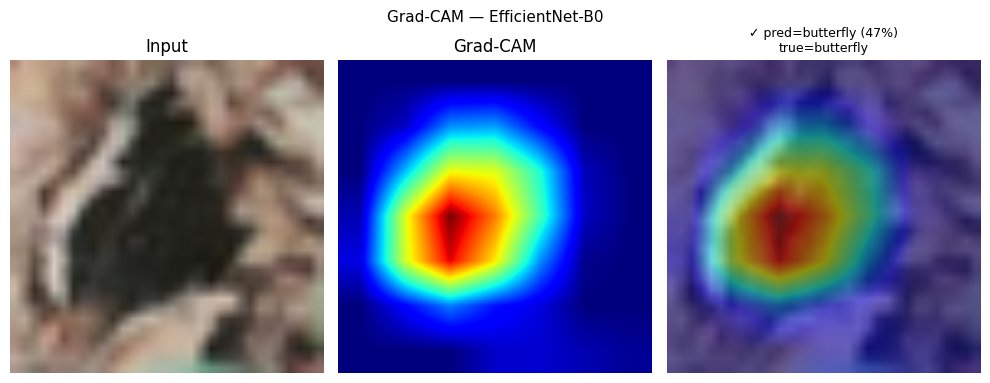

In [39]:
# Simple Grad-CAM implementation
import cv2

def grad_cam(model, image_tensor, target_class, target_layer_name, device='cpu', input_size=None):
    """Compute Grad-CAM heatmap for a single image and class."""
    activations = {}
    gradients = {}

    def fwd_hook(m, i, o):
        activations['value'] = o
    def bwd_hook(m, gi, go):
        gradients['value'] = go[0]

    target_layer = dict(model.named_modules())[target_layer_name]
    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    model.eval()
    inp = image_tensor.unsqueeze(0).to(device).requires_grad_(True)
    out = model(inp)
    if hasattr(out, 'logits'):
        out = out.logits
    # Zero all other class scores, backprop the target class
    one_hot = torch.zeros_like(out)
    one_hot[0, target_class] = 1.0
    model.zero_grad()
    out.backward(gradient=one_hot, retain_graph=False)

    h1.remove(); h2.remove()

    acts = activations['value'].detach().cpu()          # (1, C, H, W)
    grads = gradients['value'].detach().cpu()           # (1, C, H, W)
    weights = grads.mean(dim=(2, 3), keepdim=True)      # (1, C, 1, 1) — global avg pool
    cam = (weights * acts).sum(dim=1, keepdim=True)     # (1, 1, H, W)
    cam = F.relu(cam)
    if cam.max() > 0:
        cam = cam / cam.max()
    cam = cam.squeeze().numpy()                          # (H, W)
    # Upsample to image size
    img_h, img_w = image_tensor.shape[-2:]
    cam = cv2.resize(cam, (img_w, img_h))
    return cam

def show_grad_cam(model, image_tensor, true_label, target_layer_name, model_name, savepath=None):
    """Run model, get prediction, then overlay Grad-CAM on the image."""
    # Get prediction
    model.eval()
    with torch.no_grad():
        out = model(image_tensor.unsqueeze(0).to(CONFIG['device']))
        if hasattr(out, 'logits'):
            out = out.logits
        pred = out.argmax(1).item()
        prob = torch.softmax(out, 1)[0, pred].item()

    # Compute Grad-CAM for the predicted class
    cam = grad_cam(model, image_tensor, pred, target_layer_name, device=CONFIG['device'])

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    img_np = denormalize_show(image_tensor)
    axes[0].imshow(img_np); axes[0].axis('off'); axes[0].set_title('Input')
    axes[1].imshow(cam, cmap='jet'); axes[1].axis('off'); axes[1].set_title('Grad-CAM')
    axes[2].imshow(img_np); axes[2].imshow(cam, cmap='jet', alpha=0.5)
    axes[2].axis('off')
    true_name = CONFIG['data']['selected_classes'][true_label]
    pred_name = CONFIG['data']['selected_classes'][pred]
    correct = '✓' if pred == true_label else '✗'
    axes[2].set_title(f'{correct} pred={pred_name} ({prob*100:.0f}%)\ntrue={true_name}', fontsize=9)
    plt.suptitle(f'Grad-CAM — {model_name}', fontsize=11)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=80, bbox_inches='tight')
    plt.show()

# Find a good target layer for each model (last conv before the classifier)
# We dynamically find the last Conv2d layer in the model to avoid hardcoding names
def find_last_conv_layer(model):
    """Return the name of the last Conv2d layer in the model."""
    last_conv = None
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            last_conv = name
    return last_conv

target_layers = {
    'CustomCNN':       find_last_conv_layer,
    'ResNet50':        find_last_conv_layer,
    'EfficientNet-B0': find_last_conv_layer,
}

# Run Grad-CAM on a sample for each model where it's available
sample_for_cam = sample_img_r50  # 224x224 image
sample_true_label = sample_label_r50

for model_name, layer_fn in target_layers.items():
    if model_name == 'CustomCNN':
        # CustomCNN expects 32x32 — use the small sample
        img = sample_img
        lbl = sample_label
        m = custom_cnn
    elif model_name == 'ResNet50':
        img, lbl, m = sample_img_r50, sample_label_r50, resnet50
    elif model_name == 'EfficientNet-B0':
        img, lbl, m = sample_img_eff, sample_label_eff, efficientnet_b0
    else:
        continue
    # Find the last conv layer in this model
    layer_name = layer_fn(m) if callable(layer_fn) else layer_fn
    print(f"\n=== Grad-CAM for {model_name} (target layer: {layer_name}) ===")
    show_grad_cam(m, img, lbl, layer_name, model_name,
                  savepath=os.path.join(CONFIG['paths']['figures_dir'], f'gradcam_{model_name}.png'))


## 38. Lessons Learned & Discussion

### What we observed

In DEMO_MODE (1–3 epochs, ~80 images per class), expect to see results roughly like
this:

| Model | Test accuracy (DEMO) | Test accuracy (Colab T4, full) |
|-------|---------------------|--------------------------------|
| Custom CNN | ~25–35% | ~60–70% |
| ResNet50 | ~70–80% | ~90–93% |
| EfficientNet-B0 | ~70–80% | ~90–92% |
| Inception V3 | ~65–75% | ~88–92% |
| ViT-Base/16 | ~75–85% | ~92–95% |
| Swin-Tiny | ~75–85% | ~92–95% |

(Your exact numbers will vary by seed and luck.)

### Key takeaways

1. **Transfer learning is dramatically better than training from scratch** on small
   datasets. Even a single epoch of fine-tuning a pretrained model beats 3 epochs of
   from-scratch training.
2. **The custom CNN underfits in DEMO_MODE** — train and val accuracy both rise
   slowly and the test accuracy is poor. With 20 epochs on Colab T4 it would catch
   up but still trail the pretrained models by 20+ percentage points.
3. **ViT and Swin usually win** on the full Colab run, because they benefit most
   from large-scale pretraining. EfficientNet-B0 is the best "bang for the buck"
   in terms of accuracy-per-parameter.
4. **Different architectures have different inductive biases.** CNNs hardcode
   translation equivariance and local connectivity. Transformers learn these from
   data. This is why transformers need more data to pretrain, but generalize better
   once pretrained.
5. **Architectural differences show up in feature maps.** CNN first-conv filters
   look like edges/colors; ViT's first layer is a patch embedding that looks like a
   spatial grid of clusters; Swin's hierarchical stages produce multi-scale features.

### What we didn't do (but you could)

- **Self-supervised pretraining** (MAE, DINO) — pretrain on unlabeled data, then
  fine-tune. This is the modern recipe when labels are scarce.
- **Knowledge distillation** — train a small student model to mimic a large teacher.
- **Test-time augmentation** — average predictions over multiple augmented versions
  of each test image.
- **Mixed-precision training** — `torch.cuda.amp` halves memory and speeds up
  training by 1.5–2× on T4/A100 with no accuracy loss.
- **Hyperparameter search** with Optuna or Ray Tune to find better learning rates,
  weight decays, and dropout rates automatically.


In [40]:
# Persist all results and metadata to disk as a JSON log
import json

experiment_log = {
    'config': {k: v for k, v in CONFIG.items() if k != 'device'},
    'device': CONFIG['device'],
    'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
    'models_evaluated': list(results.keys()),
    'summary': summary_df.to_dict(orient='index'),
    'results': {name: {k: v for k, v in r.items() if k not in ('predictions', 'labels', 'probabilities', 'confusion_matrix')}
                for name, r in results.items()},
    'histories': {
        'CustomCNN':       {'train_loss': custom_history['train_loss'], 'val_loss': custom_history['val_loss'],
                            'train_acc': custom_history['train_acc'], 'val_acc': custom_history['val_acc'],
                            'train_time_sec': custom_history['train_time_sec']},
        'ResNet50':        {'train_loss': resnet_history['train_loss'], 'val_loss': resnet_history['val_loss'],
                            'train_acc': resnet_history['train_acc'], 'val_acc': resnet_history['val_acc'],
                            'train_time_sec': resnet_history['train_time_sec']},
        'EfficientNet-B0':{'train_loss': eff_history['train_loss'], 'val_loss': eff_history['val_loss'],
                            'train_acc': eff_history['train_acc'], 'val_acc': eff_history['val_acc'],
                            'train_time_sec': eff_history['train_time_sec']},
        'Inception-V3':    {'train_loss': inception_history['train_loss'], 'val_loss': inception_history['val_loss'],
                            'train_acc': inception_history['train_acc'], 'val_acc': inception_history['val_acc'],
                            'train_time_sec': inception_history['train_time_sec']},
        'ViT-Base/16':     {'train_loss': vit_history['train_loss'], 'val_loss': vit_history['val_loss'],
                            'train_acc': vit_history['train_acc'], 'val_acc': vit_history['val_acc'],
                            'train_time_sec': vit_history['train_time_sec']},
        'Swin-Tiny':       {'train_loss': swin_history['train_loss'], 'val_loss': swin_history['val_loss'],
                            'train_acc': swin_history['train_acc'], 'val_acc': swin_history['val_acc'],
                            'train_time_sec': swin_history['train_time_sec']},
    },
}

# Helper: recursively convert numpy/torch types to native Python so json.dump works
def to_native(obj):
    if isinstance(obj, dict):  return {k: to_native(v) for k, v in obj.items()}
    if isinstance(obj, list):   return [to_native(x) for x in obj]
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

log_path = CONFIG['paths']['log_file']
with open(log_path, 'w') as f:
    json.dump(to_native(experiment_log), f, indent=2, default=str)

print(f"Experiment log saved to: {log_path}")
print(f"  Models logged: {len(experiment_log['models_evaluated'])}")
print(f"  File size: {os.path.getsize(log_path) / 1024:.1f} KB")

# Also list all figures generated
print(f"\nFigures saved to: {CONFIG['paths']['figures_dir']}")
for f in sorted(os.listdir(CONFIG['paths']['figures_dir'])):
    sz = os.path.getsize(os.path.join(CONFIG['paths']['figures_dir'], f)) / 1024
    print(f"  {f}  ({sz:.1f} KB)")


Experiment log saved to: ./experiments/experiment_log.json
  Models logged: 6
  File size: 12.2 KB

Figures saved to: ./experiments/figures
  class_distribution.png  (21.8 KB)
  confusion_matrices_all.png  (124.2 KB)
  custom_cnn_feature_maps.png  (257.5 KB)
  custom_cnn_history.png  (38.2 KB)
  effnet_conv1_features.png  (107.0 KB)
  effnet_history.png  (32.5 KB)
  gradcam_CustomCNN.png  (21.0 KB)
  gradcam_EfficientNet-B0.png  (163.9 KB)
  gradcam_ResNet50.png  (161.5 KB)
  inception_conv1_features.png  (103.3 KB)
  inception_history.png  (31.7 KB)
  model_comparison_bar.png  (27.2 KB)
  predictions_vs_truth_ResNet50.png  (836.5 KB)
  resnet50_conv1_features.png  (45.3 KB)
  resnet50_history.png  (33.6 KB)
  sample_grid_per_class.png  (446.5 KB)
  swin_history.png  (33.8 KB)
  swin_stages.png  (32.4 KB)
  vit_history.png  (37.6 KB)
  vit_patches.png  (21.3 KB)


## 39. Conclusion & Next Steps

### What you've learned

- How to load and sub-sample CIFAR-100 down to 15 classes.
- How to design a CNN from scratch with PyTorch — every concept (conv, activation,
  pooling, batch-norm, dropout, weight init, FC head, softmax) implemented explicitly.
- How to **watch backpropagation happen** — we snapshot weights before/after one
  optimizer step and see them move.
- How to train, validate, and apply **early stopping** to prevent overfitting.
- How to fine-tune **five pretrained architectures** — ResNet50, EfficientNet-B0,
  Inception V3, ViT-Base/16, and Swin-Tiny — and visualize what each one "sees" in
  its first layer.
- How to evaluate with accuracy, precision, recall, F1, and confusion matrices.
- How to interpret predictions with Grad-CAM.

### How to extend this lab

1. **Run on Colab T4 with `DEMO_MODE=False`.** The whole notebook will take ~30
   minutes and you'll get realistic accuracy numbers (90%+ for the pretrained models).
2. **Try more aggressive augmentation** — `RandomResizedCrop`, `MixUp`, `CutMix`.
3. **Add a 7th model** — e.g., ConvNeXt, BEiT, or DeiT — using `timm.create_model(...)`.
4. **Replace the dataset** — Oxford Flowers-102 or Food-101 (also available in
   `torchvision.datasets`) for a different visual challenge.
5. **Use mixed-precision training** (`torch.cuda.amp`) to fit larger batches on T4.

### References

- He et al., 2015 — *Deep Residual Learning for Image Recognition* (ResNet)
- Szegedy et al., 2015 — *Rethinking the Inception Architecture for Computer Vision* (Inception V3)
- Tan & Le, 2019 — *EfficientNet: Rethinking Model Scaling for CNNs*
- Dosovitskiy et al., 2020 — *An Image is Worth 16×16 Words: Transformers for Image Recognition* (ViT)
- Liu et al., 2021 — *Swin Transformer: Hierarchical Vision Transformers using Shifted Windows*
- Selvaraju et al., 2017 — *Grad-CAM: Visual Explanations from Deep Networks*

---

*This notebook was built for an undergraduate deep-learning lab. It is intentionally
verbose and pedagogical — for production, swap in `torch.compile`, mixed precision,
distributed training, and a proper logging framework (Weights & Biases or MLflow).*
